# Linear algebra symbols, concepts, and NumPy

This notebook ties **notation** (symbols), **ideas** (definitions), and **code** (NumPy + **matplotlib** figures) for objects that show up constantly in machine learning. **Order:** sections **1–13**, then **§14** (items **14)–24)**), then **§25–33** (image, kernel, …, eigenspaces), then **§34–49** (parameters, derivatives, gradient, Lagrangian / NLL, combinatorics, expectation–variance–covariance, independence, sampling, common distributions).

**Seeing plots:** Run the **first code cell** below (it contains `%matplotlib inline`) **once** after opening the notebook, then run each plotting cell. Without that magic, figures may not appear *inside* the notebook (or only in a separate window). Later sections (**§25–§33**, **§34–§49**) have **no pre-saved figure outputs** until you execute those cells.

**§34–§49** cover **ML / probability notation:** $\boldsymbol{\theta}$, partial and total derivatives, $\nabla$, Lagrangian vs negative log-likelihood, $\binom{n}{k}$, $\mathbb{V}$, $\mathbb{E}$, covariance, conditional independence, $X\sim p$, and distributions $\mathcal{N}$, $\mathrm{Ber}$, $\mathrm{Bin}$, $\mathrm{Beta}$.


# VISIBLE UPDATE - EXTENDED VISUALS

This notebook has been extended from section **27 onward** with extra **Theory**, **What the visual shows**, and new bonus sections **50-60**.

If you do not see this cell, your notebook editor is showing an old cached/open copy. Close and reopen this exact file from disk.


In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt


## 1. Scalar

**Symbol / idea:** A single real (or complex) number. Often written $a$, $\lambda$, or $n$.

In code, a scalar is a 0-dimensional array or a plain Python number.

a = 3.5 shape: ()
b = 2.0 ndim: 0


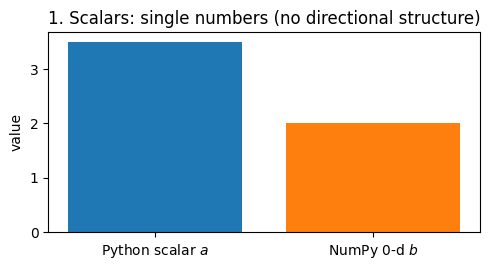

In [2]:
import matplotlib.pyplot as plt

a = 3.5
b = np.array(2.0)  # 0-d NumPy array — still a scalar mathematically
print("a =", a, "shape:", np.shape(a))
print("b =", float(b), "ndim:", b.ndim)

fig, ax = plt.subplots(figsize=(5, 2.8))
ax.bar(["Python scalar $a$", "NumPy 0-d $b$"], [a, float(b)], color=["C0", "C1"])
ax.set_ylabel("value")
ax.set_title("1. Scalars: single numbers (no directional structure)")
plt.tight_layout()
plt.show()


## 2. Vector

**Symbol / idea:** An ordered list of numbers. We often write $\mathbf{x} \in \mathbb{R}^n$ as a **column** with $n$ entries:

$$\mathbf{x} = \begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_n \end{bmatrix}$$

In NumPy, a 1-D array `shape (n,)` is common; for strict “column vector” shape, use `(n, 1)`.

x (1-D): [ 1.  -2.   0.5] shape (3,)
x as column:
 [[ 1. ]
 [-2. ]
 [ 0.5]] shape (3, 1)


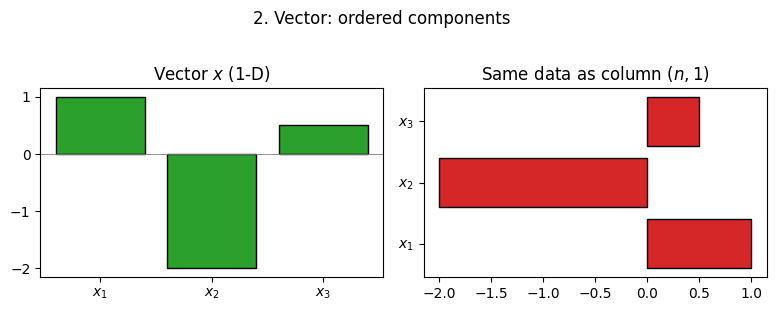

In [3]:
import matplotlib.pyplot as plt

x = np.array([1.0, -2.0, 0.5])
x_col = x.reshape(-1, 1)  # column shape (n, 1)
print("x (1-D):", x, "shape", x.shape)
print("x as column:\n", x_col, "shape", x_col.shape)

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].bar(range(len(x)), x, color="C2", edgecolor="k")
ax[0].set_xticks(range(len(x)))
ax[0].set_xticklabels([r"$x_1$", r"$x_2$", r"$x_3$"])
ax[0].axhline(0, color="gray", lw=0.6)
ax[0].set_title("Vector $x$ (1-D)")
ax[1].barh(range(len(x_col)), x_col.ravel(), color="C3", edgecolor="k")
ax[1].set_yticks(range(len(x_col)))
ax[1].set_yticklabels([r"$x_1$", r"$x_2$", r"$x_3$"])
ax[1].set_title("Same data as column $(n,1)$")
plt.suptitle("2. Vector: ordered components", y=1.02)
plt.tight_layout()
plt.show()

#x= [ 1. -2. 0.5] shape (3,) means one dimensional array (one axis and length of 3)
# column x= [[ 1. ] [-2. ] [ 0.5 ]] shape (3, 1) means 3 row and 1 column

# Same data, different shape: (3,) vs (3, 1).
#That matters for matrix multiplication: e.g. A @ x often expects x to be a column (n, 1) or a 1-D (n,) 
# (NumPy allows (n,) in many cases, but strict linear algebra uses (n, 1) for “column”).


The Vector x (1-D) has x in X axis whereas for the column one, x is in Y axis

## 3. Matrix

**Symbol / idea:** A rectangular array of numbers with $m$ rows and $n$ columns:

$$A \in \mathbb{R}^{m \times n}, \quad A = [a_{ij}]$$

Entry in row $i$, column $j$ is $a_{ij}$.

A =
 [[1 2 3]
 [4 5 6]]
shape (m, n): (2, 3)
Here we have row 0 and 1; column 0,1,2
Here element a_0,1 (row 0, col 1 in 0-based code) is: 2
Here element a_1,1 (row 1, col 1 in 0-based code) is: 5
Here element a_1,2 (row 1, col 1 in 0-based code) is: 6


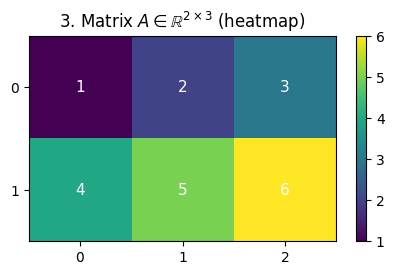

In [4]:
import matplotlib.pyplot as plt

A = np.array([[1, 2, 3], [4, 5, 6]])  # 2 rows, 3 columns
print("A =\n", A)
print("shape (m, n):", A.shape)

print("Here we have row 0 and 1; column 0,1,2")
print("Here element a_0,1 (row 0, col 1 in 0-based code) is:", A[0, 1])
print("Here element a_1,1 (row 1, col 1 in 0-based code) is:", A[1, 1])
print("Here element a_1,2 (row 1, col 1 in 0-based code) is:", A[1, 2])


fig, ax = plt.subplots(figsize=(4.5, 2.8))
im = ax.imshow(A, cmap="viridis")
for r in range(A.shape[0]):
    for c in range(A.shape[1]):
        ax.text(c, r, str(A[r, c]), ha="center", va="center", color="w", fontsize=11)
ax.set_xticks(range(A.shape[1]))
ax.set_yticks(range(A.shape[0]))
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title(r"3. Matrix $A \in \mathbb{R}^{2\times 3}$ (heatmap)")
plt.tight_layout()
plt.show()

# Row 2 and Column 3

## 4. Transpose

**Symbol / idea:** $A^{\top}$ (or $A^T$) swaps rows and columns: $(A^{\top})_{ij} = A_{ji}$.

For a column vector $\mathbf{x}$, $\mathbf{x}^{\top}$ is a **row vector**.

A shape (3, 2)
A.T shape (2, 3)
A.T =
 [[1 3 5]
 [2 4 6]]
x (column):
 [[1.]
 [2.]
 [3.]]
x.T (row): [[1. 2. 3.]]


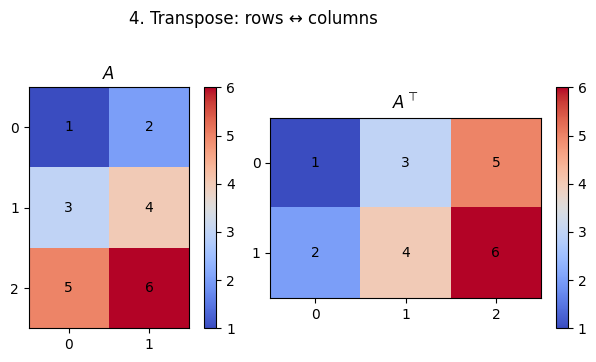

In [5]:
import matplotlib.pyplot as plt

A = np.array([[1, 2], [3, 4], [5, 6]])
print("A shape", A.shape)
print("A.T shape", A.T.shape)
print("A.T =\n", A.T)

x = np.array([[1.0], [2.0], [3.0]])
print("x (column):\n", x)
print("x.T (row):", x.T)

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
for ax, M, ttl in [(axes[0], A, r"$A$"), (axes[1], A.T, r"$A^{\top}$")]:
    im = ax.imshow(M, cmap="coolwarm")
    for r in range(M.shape[0]):
        for c in range(M.shape[1]):
            ax.text(c, r, str(M[r, c]), ha="center", va="center", color="k", fontsize=10)
    ax.set_xticks(range(M.shape[1]))
    ax.set_yticks(range(M.shape[0]))
    ax.set_title(ttl)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("4. Transpose: rows ↔ columns", y=1.02)
plt.tight_layout()
plt.show()


## 5. Inverse of a matrix

**Symbol / idea:** For a **square** matrix $A \in \mathbb{R}^{n \times n}$, if there exists $A^{-1}$ such that

$$A A^{-1} = A^{-1} A = I$$

then $A$ is **invertible** (nonsingular). Singular matrices have no inverse.

NumPy: `np.linalg.inv` for explicit inverse (fine for small $n$; in ML we often solve $Ax=b$ with `solve` instead of forming $A^{-1}$).

A.A_inv ≈ I:
 [[1. 0.]
 [0. 1.]]
det(S) = 0.0 → not invertible
LinAlgError: Singular matrix


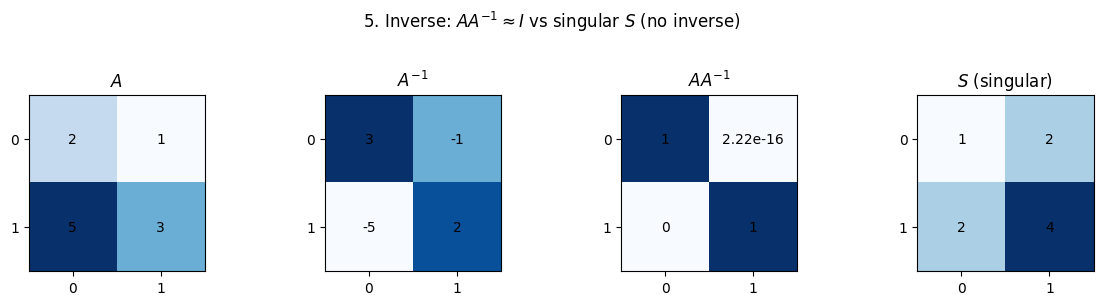

In [6]:
import matplotlib.pyplot as plt

A = np.array([[2.0, 1.0], [5.0, 3.0]])
A_inv = np.linalg.inv(A)
I_approx = A @ A_inv
print("A.A_inv ≈ I:\n", np.round(I_approx, 10))

# Singular example (second row is multiple of first)
S = np.array([[1.0, 2.0], [2.0, 4.0]])
print("det(S) =", np.linalg.det(S), "→ not invertible")
try:
    np.linalg.inv(S)
except np.linalg.LinAlgError as e:
    print("LinAlgError:", e)

fig, axes = plt.subplots(1, 4, figsize=(12, 2.8))
for ax, M, ttl in [
    (axes[0], A, r"$A$"),
    (axes[1], A_inv, r"$A^{-1}$"),
    (axes[2], I_approx, r"$A A^{-1}$"),
    (axes[3], S, r"$S$ (singular)"),
]:
    ax.imshow(M, cmap="Blues")
    for r in range(M.shape[0]):
        for c in range(M.shape[1]):
            ax.text(c, r, f"{M[r, c]:.3g}", ha="center", va="center", fontsize=10)
    ax.set_xticks(range(M.shape[1]))
    ax.set_yticks(range(M.shape[0]))
    ax.set_title(ttl)
plt.suptitle(r"5. Inverse: $A A^{-1}\approx I$ vs singular $S$ (no inverse)", y=1.05)
plt.tight_layout()
plt.show()

# A.A_inv ≈ I means AA^-1=I (So, A matrix multiplication with A_inv erse is equivalent to Identity matrix)

As S is not invertible, it's Determinant is also 0. We can say that vice versa. 

Also, AA^-1 = I here.

## 6. Inner product $\langle \mathbf{x}, \mathbf{y} \rangle$

**Symbol / idea:** An inner product maps two vectors to a scalar and must satisfy linearity, symmetry (for real spaces), and positive-definiteness. On $\mathbb{R}^n$, the **standard inner product** is

$$\langle \mathbf{x}, \mathbf{y} \rangle = \sum_{i=1}^n x_i y_i.$$

**Matrix form** (when $\mathbf{x}, \mathbf{y}$ are columns): $\langle \mathbf{x}, \mathbf{y} \rangle = \mathbf{x}^{\top} \mathbf{y}$.

## 7. Dot product $\mathbf{x} \cdot \mathbf{y}$

**Symbol / idea:** For $\mathbf{x}, \mathbf{y} \in \mathbb{R}^n$, the **dot product** is written $\mathbf{x} \cdot \mathbf{y}$ and is **the same number** as the standard inner product:

$$\mathbf{x} \cdot \mathbf{y} = \sum_{i=1}^n x_i y_i = \langle \mathbf{x}, \mathbf{y} \rangle.$$

**Note:** For **complex** vectors, the inner product typically uses a conjugate ($\mathbf{x}^H \mathbf{y}$); naming "dot product" is then used less often for that generalization.

**Code (next cell):** Concrete vectors $\mathbf{x}, \mathbf{y} \in \mathbb{R}^3$. NumPy computes the **same scalar** whether you think of it as the standard **inner product** $\langle \mathbf{x}, \mathbf{y} \rangle$ or the **dot product** $\mathbf{x} \cdot \mathbf{y}$. The figure plots the components and the terms $x_i y_i$ whose sum is that number.

x · y = 5.0
x @ y = 5.0
sum(x*y) = 5.0
x^T y (as matrix) = 5.0


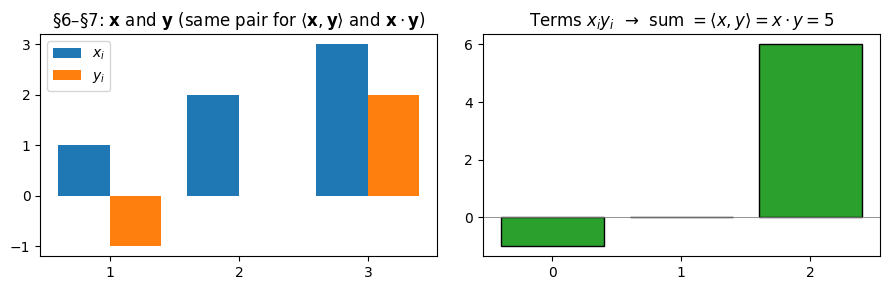

In [7]:
import matplotlib.pyplot as plt

# §6–§7: In R^n, <x,y> and x·y are the same computation (sum of x_i * y_i).

x = np.array([1.0, 2.0, 3.0])
y = np.array([-1.0, 0.0, 2.0])

dot_xy = np.dot(x, y)
inner_xy = x @ y  # same for 1-D real arrays
inner_explicit = (x * y).sum()
matrix_form = x.reshape(1, -1) @ y.reshape(-1, 1)  # x^T y as 1x1

print("x · y =", dot_xy)
print("x @ y =", inner_xy) #@ means inner product
print("sum(x*y) =", inner_explicit)
print("x^T y (as matrix) =", matrix_form.item())

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].bar(np.arange(3) - 0.2, x, width=0.4, label=r"$x_i$", color="C0")
axes[0].bar(np.arange(3) + 0.2, y, width=0.4, label=r"$y_i$", color="C1")
axes[0].set_xticks(range(3))
axes[0].set_xticklabels([r"$1$", r"$2$", r"$3$"])
axes[0].legend()
axes[0].set_title(r"§6–§7: $\mathbf{x}$ and $\mathbf{y}$ (same pair for $\langle\mathbf{x},\mathbf{y}\rangle$ and $\mathbf{x}\cdot\mathbf{y}$)")
axes[1].bar(range(3), x * y, color="C2", edgecolor="k")
axes[1].set_xticks(range(3))
axes[1].set_title(r"Terms $x_i y_i$  →  sum $= \langle x,y\rangle = x\cdot y = %g$" % dot_xy)
axes[1].axhline(0, color="gray", lw=0.6)
plt.tight_layout()
plt.show()


# x.y is a dot product of x and y
# x @ y means x matrix multiply by y 
# sum(x*y) = elementwise product of x and y
#  x^Ty = means x as row matrix (1 X n) and y as column matrix (n X 1). Finally multiple them.

Here x = 1,2,3
y has -1, 0, 2

Then we multiple them and and we have 1*-1 = -1, 2* 0 = 0 & 3* 2 = 6
Finally, we add them up, -1+0+6=5


## 8. (Ordered) tuple

**Example:** $B = (b_1, b_2, b_3)$ — here $B$ names the whole tuple; $b_1, b_2, b_3$ are its entries in order. (In math notation these letters are *italic*, not bold like vectors $\mathbf{x}$ often are.)

**Symbol / idea:** More generally, a finite **ordered** sequence $(a_1, a_2, \ldots, a_k)$. Order matters: $(1,2) \neq (2,1)$.

A vector’s coordinates are an ordered $n$-tuple in $\mathbb{R}^n$. Python `tuple` matches “ordered”; `set` does not.

B = (3, 1, 4)
B == B_prime? False
set(B) == set(B_prime)? True


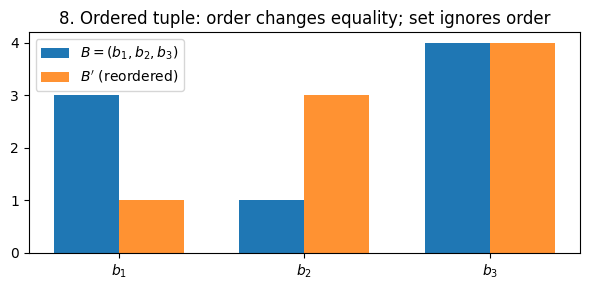

In [8]:
import matplotlib.pyplot as plt

b1, b2, b3 = 3, 1, 4
B = (b1, b2, b3)
b1p, b2p, b3p = 1, 3, 4
B_prime = (b1p, b2p, b3p)  # same components, different order
print("B =", B)
print("B == B_prime?", B == B_prime)
# Same numbers as a set → order ignored
print("set(B) == set(B_prime)?", set(B) == set(B_prime))

fig, ax = plt.subplots(figsize=(6, 3))
w = 0.35
pos = np.arange(3)
ax.bar(pos - w / 2, B, w, label=r"$B=(b_1,b_2,b_3)$", color="C0")
ax.bar(pos + w / 2, B_prime, w, label=r"$B'$ (reordered)", color="C1", alpha=0.85)
ax.set_xticks(pos)
ax.set_xticklabels([r"$b_1$", r"$b_2$", r"$b_3$"])
ax.axhline(0, color="k", lw=0.5)
ax.legend()
ax.set_title("8. Ordered tuple: order changes equality; set ignores order")
plt.tight_layout()
plt.show()


B has 3,1,4
B_prime has 1,3,4 

## 9. Matrix built from column vectors (horizontal stack)

**Example:** $\boldsymbol{B} = \begin{bmatrix} \mathbf{b}_1 & \mathbf{b}_2 & \mathbf{b}_3 \end{bmatrix}$ — the matrix $\boldsymbol{B}$ is written **bold italic** (we use $\boldsymbol{B}$ in LaTeX/MathJax); $\mathbf{b}_1, \mathbf{b}_2, \mathbf{b}_3 \in \mathbb{R}^m$ are **columns** placed side by side.

**General case:** If $\mathbf{c}_1, \ldots, \mathbf{c}_n \in \mathbb{R}^m$ are columns, then

$$\mathbf{C} = \begin{bmatrix} \mathbf{c}_1 & \mathbf{c}_2 & \cdots & \mathbf{c}_n \end{bmatrix} \in \mathbb{R}^{m \times n}.$$

NumPy: `np.column_stack` or `np.hstack` on 2-D columns.

B from np.hstack([b1, b2, b3]):
 [[ 1.  0.  2.]
 [ 0.  1.  2.]
 [ 2. -1.  0.]]
Same matrix from both tricks? True


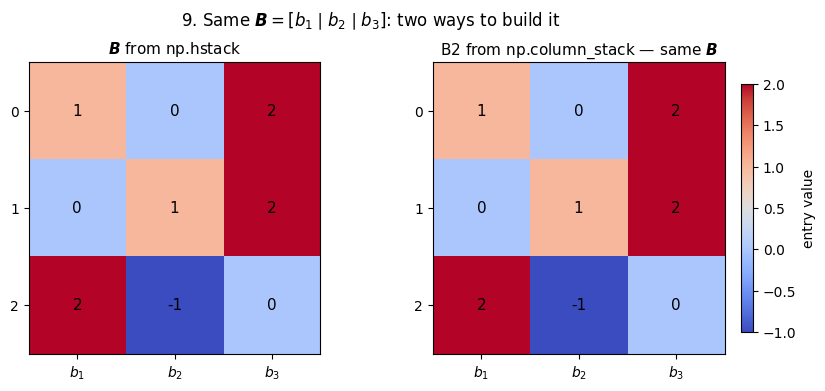

In [9]:
import matplotlib.pyplot as plt

b1 = np.array([[1.0], [0.0], [2.0]])
b2 = np.array([[0.0], [1.0], [-1.0]])
b3 = np.array([[2.0], [2.0], [0.0]])
B = np.hstack([b1, b2, b3])  # B = [b1 | b2 | b3] by gluing columns side by side
print("B from np.hstack([b1, b2, b3]):\n", B)
# Other way to build the same matrix: stack flat vectors as columns
B2 = np.column_stack([b1.ravel(), b2.ravel(), b3.ravel()])
match = np.allclose(B, B2)
print("Same matrix from both tricks?", match)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), constrained_layout=True)
v_min = min(B.min(), B2.min())
v_max = max(B.max(), B2.max())
panels = [
    (axes[0], B, r"$\boldsymbol{B}$ from np.hstack"),
    (axes[1], B2, r"B2 from np.column_stack — same $\boldsymbol{B}$"),
]
im0 = None
for ax, M, ttl in panels:
    im = ax.imshow(M, cmap="coolwarm", vmin=v_min, vmax=v_max, aspect="equal")
    if im0 is None:
        im0 = im
    for r in range(M.shape[0]):
        for c in range(M.shape[1]):
            ax.text(c, r, f"{M[r, c]:g}", ha="center", va="center", fontsize=11, color="k")
    ax.set_xticks(range(M.shape[1]))
    ax.set_xticklabels([r"$b_1$", r"$b_2$", r"$b_3$"])
    ax.set_yticks(range(M.shape[0]))
    ax.set_title(ttl, fontsize=11)
fig.suptitle(
    r"9. Same $\boldsymbol{B}=[b_1\mid b_2\mid b_3]$: two ways to build it",
    fontsize=12,
)
fig.colorbar(im0, ax=axes, shrink=0.85, pad=0.02, label="entry value")
plt.show()


Although B and B2 was made in different wasy, they are still the same

## 10. Set of vectors (unordered)

**Example:** $B = \{b_1, b_2, b_3\}$ — here the name $B$ is *italic* in math notation (plain $B$, not $\mathbf{B}$ or $\boldsymbol{B}$). Curly braces $\{\cdot\}$ mean a **set**: order does not matter and repeated elements collapse to one.

**Symbol / idea:** A **set** $\{\mathbf{v}_1, \mathbf{v}_2, \ldots\}$ has **no order** and **no duplicates** as a set. $\{\mathbf{a}, \mathbf{b}\} = \{\mathbf{b}, \mathbf{a}\}$.

In Python, vectors are often unhashable (arrays are mutable), so we use **tuples of floats** or **lists of tuples** to mimic a set of “frozen” vectors, or we keep a **list** when order matters for an algorithm.

B = {(1.0, 0.0), (1.0, 1.0), (0.0, 1.0)}
B and B_alt is formed from same elements. So,B == B_alt? True
As set does not count duplicattes, is {b1, b2, b1} equivalent to {b1, b2}? True


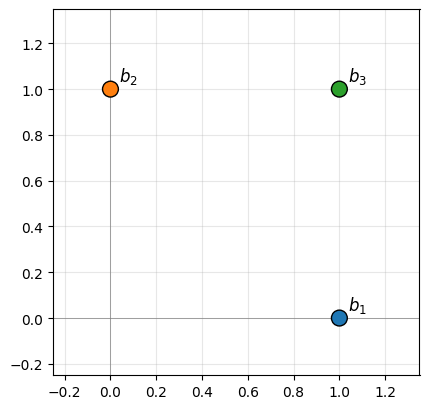

In [10]:
import matplotlib.pyplot as plt

# B = {b1, b2, b3}: hashable 2-vectors as tuples → can use set
b1 = (1.0, 0.0)
b2 = (0.0, 1.0)
b3 = (1.0, 1.0)
B = {b1, b2, b3}
B_alt = {b3, b1, b2}  # different insertion order, same set
print("B =", B)
print("B and B_alt is formed from same elements. So,B == B_alt?", B == B_alt)

B_with_dup = {b1, b2, b1}  # duplicate b1 removed
print("As set does not count duplicattes, is {b1, b2, b1} equivalent to {b1, b2}?", B_with_dup == {b1, b2})

# List of ndarray: freeze to tuples for an unordered set view
vecs = [np.array([1.0, 0.0]), np.array([0.0, 1.0])]
as_tuples = {tuple(v.round(6)) for v in vecs}
#print("unordered view from arrays:", as_tuples)

fig, ax = plt.subplots(figsize=(4.5, 4.2))
pts = np.array([b1, b2, b3])
ax.scatter(pts[:, 0], pts[:, 1], s=130, c=["C0", "C1", "C2"], edgecolors="k", zorder=3)
for (xi, yi), lab in zip(pts, [r"$b_1$", r"$b_2$", r"$b_3$"]):
    ax.annotate(lab, (xi, yi), textcoords="offset points", xytext=(6, 6), fontsize=12)
ax.set_xlim(-0.25, 1.35)
ax.set_ylim(-0.25, 1.35)
ax.set_aspect("equal")
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.grid(True, alpha=0.3)
#ax.set_title("10. Set of vectors: points have no order; {…} removes duplicates")
plt.tight_layout()
plt.show()


## 11. $n$-dimensional vector space $\mathbb{R}^n$

**Symbol / idea:** $\mathbb{R}^n$ is the set of all real $n$-tuples $(x_1,\ldots,x_n)$ with **vector addition** and **scalar multiplication** satisfying the vector space axioms. The **standard basis** has vectors $\mathbf{e}_1,\ldots,\mathbf{e}_n$ with a single $1$ in one coordinate.

Dimension is $n$: you need $n$ numbers to specify a point.

Vectors in R^4 are 4 real numbers in a row (NumPy length-4 array).

x = [1.7641 0.4002 0.9787 2.2409]   shape (4,) ⇒ x ∈ R^4
y = [ 1.8676 -0.9773  0.9501 -0.1514]   shape (4,) ⇒ y ∈ R^4

α = 0.5 (one scalar)
α x + (1-α) y = [ 1.8158 -0.2886  0.9644  1.0448]   shape (4,)
Still 4 real numbers ⇒ this combination also lies in R^4. (Multiply vectors by scalars and add: each coordinate is α·x_i + (1-α)·y_i.)
e_2 (standard basis vector in R^4) = [0. 1. 0. 0.]


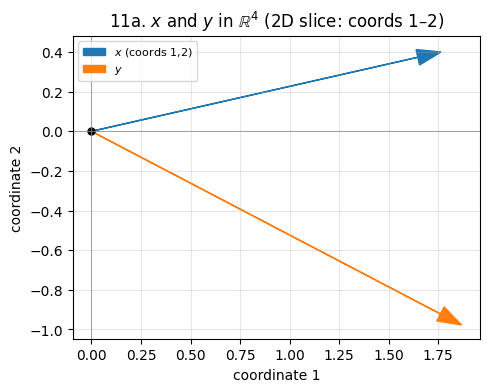

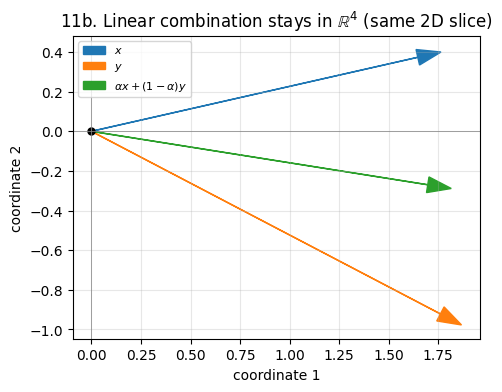

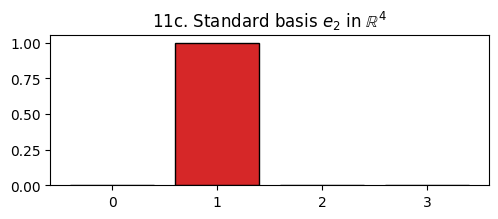

In [11]:
import matplotlib.pyplot as plt

n = 4  # 4-dimensional real space R^4
np.random.seed(0)
x = np.random.randn(n)
y = np.random.randn(n)
alpha = 0.5
lin_combo = alpha * x + (1 - alpha) * y
_fmt = lambda v: np.array2string(v, precision=4, suppress_small=True)
print("Vectors in R^%d are %d real numbers in a row (NumPy length-%d array).\n" % (n, n, n))
print("x =", _fmt(x), "  shape", x.shape, "⇒ x ∈ R^%d" % n)
print("y =", _fmt(y), "  shape", y.shape, "⇒ y ∈ R^%d" % n)
print()
print("α =", alpha, "(one scalar)")
print("α x + (1-α) y =", _fmt(lin_combo), "  shape", lin_combo.shape)
print(
    "Still %d real numbers ⇒ this combination also lies in R^%d."
    " (Multiply vectors by scalars and add: each coordinate is α·x_i + (1-α)·y_i.)"
    % (n, n)
)

# Standard basis e_2 in R^4 (0-based index 1)
e2 = np.eye(n)[1]
print("e_2 (standard basis vector in R^4) =", e2)

def _draw_slice_axes(ax, title):
    ax.scatter([0], [0], c="k", s=25)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)
    ax.set_xlabel(r"coordinate 1")
    ax.set_ylabel(r"coordinate 2")
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)

# 1) x and y only (first two coordinates of vectors in R^4)
fig1, ax1 = plt.subplots(figsize=(5, 5))
ax1.arrow(
    0, 0, x[0], x[1], head_width=0.08, length_includes_head=True, color="C0", label=r"$x$ (coords 1,2)",
)
ax1.arrow(0, 0, y[0], y[1], head_width=0.08, length_includes_head=True, color="C1", label=r"$y$")
_draw_slice_axes(
    ax1,
    r"11a. $x$ and $y$ in $\mathbb{R}^4$ (2D slice: coords 1–2)",
)
plt.tight_layout()
plt.show()

# 2) same slice + linear combination $\alpha x + (1-\alpha)y$
fig2, ax2 = plt.subplots(figsize=(5, 5))
ax2.arrow(
    0, 0, x[0], x[1], head_width=0.08, length_includes_head=True, color="C0", label=r"$x$",
)
ax2.arrow(0, 0, y[0], y[1], head_width=0.08, length_includes_head=True, color="C1", label=r"$y$")
ax2.arrow(
    0,
    0,
    lin_combo[0],
    lin_combo[1],
    head_width=0.08,
    length_includes_head=True,
    color="C2",
    label=r"$\alpha x+(1-\alpha)y$",
)
_draw_slice_axes(
    ax2,
    r"11b. Linear combination stays in $\mathbb{R}^4$ (same 2D slice)",
)
plt.tight_layout()
plt.show()

fig3, ax3 = plt.subplots(figsize=(5, 2.3))
ax3.bar(range(n), e2, color="C3", edgecolor="k")
ax3.set_xticks(range(n))
ax3.set_title(r"11c. Standard basis $e_2$ in $\mathbb{R}^4$")
plt.tight_layout()
plt.show()


x = [1.7641 0.4002 0.9787 2.2409]    ;x ∈ R^4
y = [ 1.8676 -0.9773  0.9501 -0.1514]   ; y ∈ R^4

α = 0.5 

Also, 
α x + (1-α) y = [ 1.8158 -0.2886  0.9644  1.0448]   ∈ R^4

So, α x + (1-α) y remains within the 4 dimension (rules of vector)

## 12. Universal quantifier — “for all” $\forall$

**Symbol / idea:** $\forall x \, P(x)$ means “**for every** $x$ (in some domain), the statement $P(x)$ is true.”

**Example:** $\forall \mathbf{x} \in \mathbb{R}^n,\; \mathbf{x} \cdot \mathbf{x} \ge 0$.

For all sampled x,    x·x >= 0: True


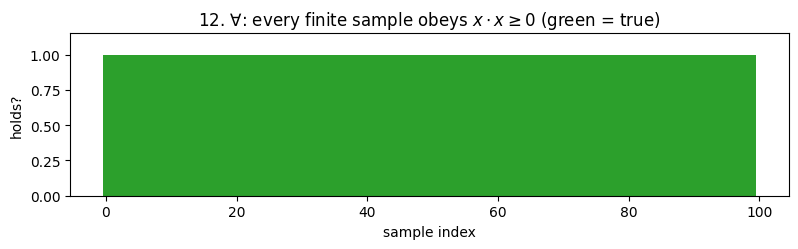

In [12]:
import matplotlib.pyplot as plt

def forall_in_grid(check, xs):
    """Finite stand-in: P holds for all x in xs."""
    return all(check(x) for x in xs)


# ∀x in sample, x·x >= 0
np.random.seed(1)
samples = [np.random.randn(5) for _ in range(100)]
ok = forall_in_grid(lambda x: np.dot(x, x) >= 0, samples)
print("For all sampled x,    x·x >= 0:", ok)

checks = [np.dot(x, x) >= 0 for x in samples]
fig, ax = plt.subplots(figsize=(8, 2.6))
colors = ["#2ca02c" if c else "#d62728" for c in checks]
ax.bar(range(len(checks)), [1 if c else 0 for c in checks], color=colors, width=1.0)
ax.set_xlabel("sample index")
ax.set_ylabel(r"holds?")
ax.set_title(r"12. $\forall$: every finite sample obeys $x\cdot x \geq 0$ (green = true)")
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.show()


## 13. Existential quantifier — “there exists” $\exists$

**Symbol / idea:** $\exists x \, P(x)$ means “**there is at least one** $x$ such that $P(x)$ is true.”

**Example:** $\exists \mathbf{x} \in \mathbb{R}^2$ such that $A\mathbf{x} = \mathbf{b}$ (when $A$ is invertible, such $\mathbf{x}$ exists for every $\mathbf{b}$).

Found x with Ax ≈ b: True
The x vector is = [-1.  1.]
Exists k with k^2 > 50? (Meaning is there at least one number k such that k² > 50?) = True


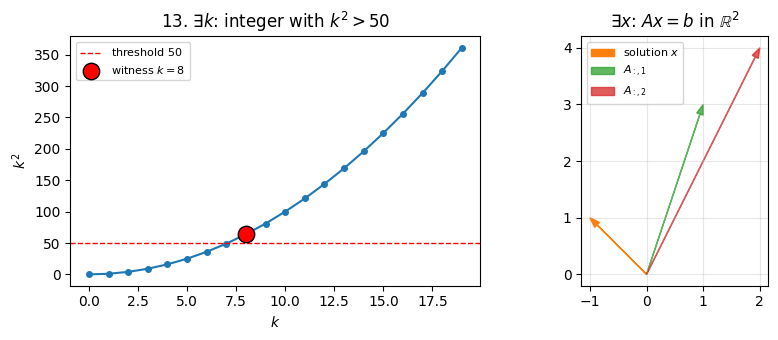

In [13]:
import matplotlib.pyplot as plt

def exists_in_grid(check, xs):
    return any(check(x) for x in xs)


A = np.array([[1.0, 2.0], [3.0, 4.0]])
b = np.array([1.0, 1.0])

x_star = np.linalg.solve(A, b)

residual_ok = np.allclose(A @ x_star, b)
print("Found x with Ax ≈ b:", residual_ok)
print("The x vector is =", x_star)

# ∃ integer k in range with k^2 > 50
ks = list(range(20))
exists_sq = exists_in_grid(lambda k: k * k > 50, ks)
print("Exists k with k^2 > 50? (Meaning is there at least one number k such that k² > 50?) =", exists_sq)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

ax = axes[0]
ax.plot(ks, [k * k for k in ks], "o-", color="C0", ms=4)
ax.axhline(50, color="red", ls="--", lw=1, label=r"threshold $50$")
k_hit = next(k for k in ks if k * k > 50)
ax.scatter([k_hit], [k_hit**2], s=140, c="red", zorder=5, edgecolors="k", label=rf"witness $k={k_hit}$")
ax.set_xlabel(r"$k$")
ax.set_ylabel(r"$k^2$")
ax.legend(fontsize=8)
ax.set_title(r"13. $\exists k$: integer with $k^2 > 50$")

ax2 = axes[1]
o = np.array([0.0, 0.0])
ax2.arrow(*o, *x_star, head_width=0.12, length_includes_head=True, color="C1", label=r"solution $x$")
ax2.arrow(*o, *A[:, 0], head_width=0.12, length_includes_head=True, color="C2", alpha=0.75, label=r"$A_{:,1}$")
ax2.arrow(*o, *A[:, 1], head_width=0.12, length_includes_head=True, color="C3", alpha=0.75, label=r"$A_{:,2}$")
ax2.set_aspect("equal")
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=8, loc="upper left")
ax2.set_title(r"$\exists x$: $Ax=b$ in $\mathbb{R}^2$")

plt.tight_layout()
plt.show()


#A is a matrix,x is a vector, b is a vector

For the left graph, 

For k=7; it does not follow k^2 = 49 >50 
But from k=8, k^2= 64>50
k=9, k^2= 81>50 etc.

So, atleast one value 8 exists (there are many more solutions as well like k=8,9,10,....)

The right graph is,

A= [1 2 ]
   [3 4 ]
Here, Green line= First column [1 3]
Red line = Second column [2 4]
b = [1 1]
There exists x for which Ax=b ; the x vector is  [1 1]  

### 14) $a := b$
**Read:** $a$ is **defined to be** $b$ (the name on the left is introduced from the right-hand side).

**Math example:** $a := 3 + 4$ means we **define** $a$ by that expression, so $a = 7$. In a proof you might write $n := |S|$ to mean “from now on, $n$ denotes the size of $S$.”

**Visualize:** number line with the pieces $3$, $4$, and the defined value $a = 7$.


14)  a := 3+4  →  a = 7


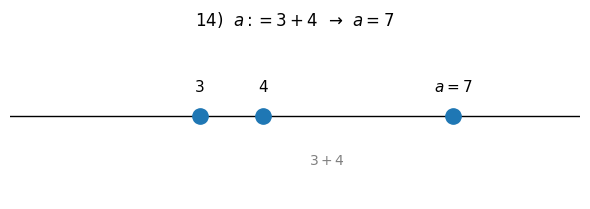

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# --- 14)  a := b  — define a from the right-hand side ---
a = 3 + 4
print("14)  a := 3+4  →  a =", a)

fig, ax = plt.subplots(figsize=(6, 2.2))
ax.axhline(0, color="k", lw=1)
for x, lab in [(3, "3"), (4, "4"), (7, "$a=7$")]:
    ax.plot(x, 0, "o", ms=11, color="C0")
    ax.annotate(lab, (x, 0.18), ha="center", fontsize=11)
ax.annotate("$3+4$", xy=(5, -0.35), fontsize=10, color="gray", ha="center")
ax.set_xlim(0, 9)
ax.set_ylim(-0.6, 0.6)
ax.set_title(r"14)  $a := 3+4$  →  $a=7$")
ax.axis("off")
plt.tight_layout()
plt.show()


### 15) $a =: b$
**Read:** $b$ is **defined to be** $a$ (the colon marks which symbol is being *defined*).

**Math example:** $\sqrt{5} =: \alpha$ means we **introduce** the name $\alpha$ and set it equal to $\sqrt{5}$ (same equality as $\alpha := \sqrt{5}$, only the emphasis changes).

**Visualize:** number line with $\sqrt{5}$ and the label $\alpha$.


15)  alpha = sqrt(5)  ≈ 2.23606797749979


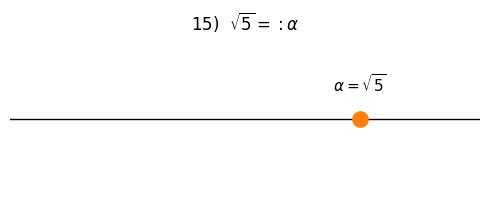

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# --- 15)  a =: b  — here: sqrt(5) =: alpha (name alpha for sqrt(5)) ---
alpha = np.sqrt(5)
print("15)  alpha = sqrt(5)  ≈", float(alpha))

fig, ax = plt.subplots(figsize=(5, 2.2))
ax.axhline(0, color="k", lw=1)
ax.plot(alpha, 0, "o", ms=11, color="C1")
ax.annotate(r"$\alpha = \sqrt{5}$", (alpha, 0.2), ha="center", fontsize=11)
ax.set_xlim(0, 3)
ax.set_ylim(-0.6, 0.6)
ax.set_title(r"15)  $\sqrt{5} =: \alpha$")
ax.axis("off")
plt.tight_layout()
plt.show()


### 16) $\Leftrightarrow$ (if and only if)
$P \Leftrightarrow Q$ means $P$ is true **if and only if** $Q$ is true (logical equivalence).

**Math example:** For an integer $n$,

$$n \text{ is even} \quad \Leftrightarrow \quad \exists\, k \in \mathbb{Z} \text{ such that } n = 2k.$$

Also $x^2 = 1 \Leftrightarrow (x = 1 \text{ or } x = -1)$ for $x \in \mathbb{R}$.

**Visualize:** truth table for $P \Leftrightarrow Q$ (green = true, red = false).


∀k in 0..5: (even k) ⇔ (k//2)*2==k)? True


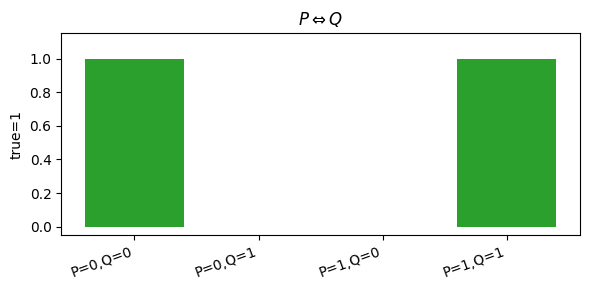

In [16]:
import numpy as np
import matplotlib.pyplot as plt

#P ⇔ Q  (check even k ⇔ k//2*2 == k for small k) ---


def even(k):
    return k % 2 == 0


ks = list(range(6))
ok = all(even(k) == (k // 2 * 2 == k) for k in ks)
print("∀k in 0..5: (even k) ⇔ (k//2)*2==k)?", ok)
#For each k from 0 to 5, when “k is even”, it's equivalent to “k//2*2 == k.”
# ex: k= 0 (even); (0//2)*2=0 
# ex: k= 2 (even); (2//2)*2=2
# ex: k= 4 (even); (4//2)*2=4  


rows = [(0, 0), (0, 1), (1, 0), (1, 1)]
iff_vals = [int(P == Q) for P, Q in rows]
colors = ["#2ca02c" if v else "#d62728" for v in iff_vals]

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(range(4), iff_vals, color=colors)
ax.set_xticks(range(4))
ax.set_xticklabels([f"P={P},Q={Q}" for P, Q in rows], rotation=20, ha="right")
ax.set_ylabel("true=1")
ax.set_ylim(-0.05, 1.15)
ax.set_title(r"$P \Leftrightarrow Q$")
plt.tight_layout()
plt.show()


In the plot, when P is 0, Q is 0 as well. As they match, the bar is set to 1
Same for the P=1; Q=1

### 17) $\Rightarrow$ (implies)
$P \Rightarrow Q$ means **if** $P$ **then** $Q$.

**Math example:** For $x \in \mathbb{R}$, $x > 3 \Rightarrow x > 0$ is **true**.
Meaning, if x is bigger than 3, then x is bigger than 0
 But $x > 0 \Rightarrow x > 3$ is **false** (e.g. $x = 1$) meaning if x is bigger than 0, x is not bigger than 3

**Visualize:** truth table for $P \Rightarrow Q$; number line where $(x>3) \Rightarrow (x>0)$ holds; second number line for $(x>3) \Rightarrow (x>5)$ (counterexample at $x=4$: $P$ true, $Q$ false).


x=1: (x>3)⇒(x>0) = True  [P=False, Q=True]
x=5: (x>3)⇒(x>0) = True  [P=True, Q=True]
x=4: (x>3)⇒(x>5) = False  [P=True, Q=False]  ← P true, Q false ⇒ implication false


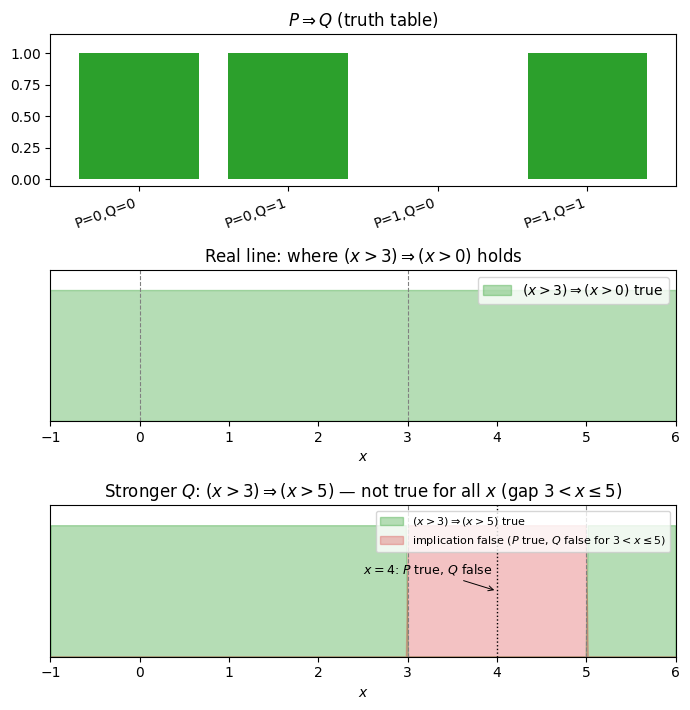

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# --- 17)  P ⇒ Q ---


def implies(P, Q):
    return (not P) or Q


rows = [(0, 0), (0, 1), (1, 0), (1, 1)]
imp_vals = [int((not P) or Q) for P, Q in rows]
colors = ["#2ca02c" if v else "#d62728" for v in imp_vals]

for x in (1, 5):
    P, Q = x > 3, x > 0
    print(f"x={x}: (x>3)⇒(x>0) = {implies(P, Q)}  [P={P}, Q={Q}]")

x_ce = 4
P_ce, Q_ce = x_ce > 3, x_ce > 5
print(
    f"x={x_ce}: (x>3)⇒(x>5) = {implies(P_ce, Q_ce)}  "
    f"[P={P_ce}, Q={Q_ce}]  ← P true, Q false ⇒ implication false"
)

fig, (ax0, ax1, ax2) = plt.subplots(
    3, 1, figsize=(7, 7.2), gridspec_kw={"height_ratios": [1, 1, 1]}
)
ax0.bar(range(4), imp_vals, color=colors)
ax0.set_xticks(range(4))
ax0.set_xticklabels([f"P={P},Q={Q}" for P, Q in rows], rotation=20, ha="right")
ax0.set_ylim(-0.05, 1.15)
ax0.set_title(r"$P \Rightarrow Q$ (truth table)")

xs = np.linspace(-1, 6, 300)
holds = np.array([((not (x > 3)) or (x > 0)) for x in xs], dtype=float)
ax1.fill_between(xs, 0, holds, alpha=0.35, color="C2", label=r"$(x>3) \Rightarrow (x>0)$ true")
ax1.axvline(0, color="gray", ls="--", lw=0.8)
ax1.axvline(3, color="gray", ls="--", lw=0.8)
ax1.set_xlim(-1, 6)
ax1.set_ylim(0, 1.15)
ax1.set_xlabel(r"$x$")
ax1.set_yticks([])
ax1.legend(loc="upper right")
ax1.set_title(r"Real line: where $(x>3) \Rightarrow (x>0)$ holds")

holds_strong = np.array([((not (x > 3)) or (x > 5)) for x in xs], dtype=float)
ax2.fill_between(
    xs, 0, holds_strong, alpha=0.35, color="C2", label=r"$(x>3) \Rightarrow (x>5)$ true"
)
ax2.fill_between(
    xs,
    0,
    1 - holds_strong,
    alpha=0.28,
    color="C3",
    label=r"implication false ($P$ true, $Q$ false for $3<x\leq 5$)",
)
ax2.axvline(3, color="gray", ls="--", lw=0.8)
ax2.axvline(5, color="gray", ls="--", lw=0.8)
ax2.axvline(4, color="k", ls=":", lw=1.0)
ax2.annotate(
    r"$x=4$: $P$ true, $Q$ false",
    xy=(4, 0.5),
    xytext=(0.5, 0.55),
    textcoords="axes fraction",
    fontsize=9,
    arrowprops=dict(arrowstyle="->", color="k", lw=0.7),
)
ax2.set_xlim(-1, 6)
ax2.set_ylim(0, 1.15)
ax2.set_xlabel(r"$x$")
ax2.set_yticks([])
ax2.legend(loc="upper right", fontsize=8)
ax2.set_title(
    r"Stronger $Q$: $(x>3) \Rightarrow (x>5)$ — not true for all $x$ (gap $3<x\leq 5$)"
)
plt.tight_layout()
plt.show()


Law1: If P is True,Q has to be True
Law2: If P is False, Q can be anything

1) Here, x=1: (x>3)⇒(x>0) = True  [P=False, Q=True] here this means

a)The law (x>3)⇒(x>0) = True  because when x>3 and x>0 . So, the law does not break

b) x=1

c) Now P refers to (x>3). So, P = False  as 1 is not bigger than 3
Q is True as 1 is bigger than 0
Now, according to the Law1 & Law2, 0 means False, 1 means True
So, when P = 0 (False),  Q can be 0 (False) or 1 (True)
When P=1 (True), Q has to be 1 (True)
So, we can see green plot for P=0,Q=0/1 & P=1,Q=1  


2) for the second plot down,for x=-1 to 6

(x>3) => (x>0) = True

Becuase
Law: when P is true, Q has to be true. But when P is False Q can be True/False

When x=-1 , P = (x>3) = False and Q (x>1) = True [Follows law]
When x=0 , P = (x>3) = False and Q (x>1) = True [Follows law]
When x=2 , P = (x>3) = False and Q (x>1) = True [Follows law]
When x=3 , P = (x>3) = False and Q (x>1) = True [Follows law]
When x=4 , P = (x>3) = True and Q (x>1) = True [Follows law]
When x=5 , P = (x>3) = True and Q (x>1) = True [Follows law]
When x=6 , P = (x>3) = True and Q (x>1) = True [Follows law]

So, for x=-1 to 6; (x>3) => (x>0) = True [Thus shown the green square]


3) For plot 3, (x>3)=> (x>5) 
Here, P= x>3 ; Q=x>5

When x=3 ; P= False , Q = False [Does not break the law]

x=4; P= True , Q = False [breaks the law]
x=5; P= True , Q = False [breaks the law]

Thus, red square

x=2 ; P= False , Q = [Does not break the law] 
x=6 ; P= True , Q = True [Does not break the law]

Note: When it does not break the law = Green square; When breaks the law = red square

### 18) $A$, $C$ are sets (italic)
Capital italic letters such as $A$, $C$ often denote **sets** (plain math italic, not bold).

**Math example:** Let $A = \{1, 2, 3\}$ and $C = \{2, 3, 4\}$. Then

$$A \cap C = \{2, 3\}, \qquad A \cup C = \{1, 2, 3, 4\}, \qquad A \setminus C = \{1\}.$$

**Visualize:** Venn-style diagram with elements placed in regions.


18)  A = {1, 2, 3}  C = {2, 3, 4}
     A∩C = {2, 3}  A∪C = {1, 2, 3, 4}  A\C = {1}


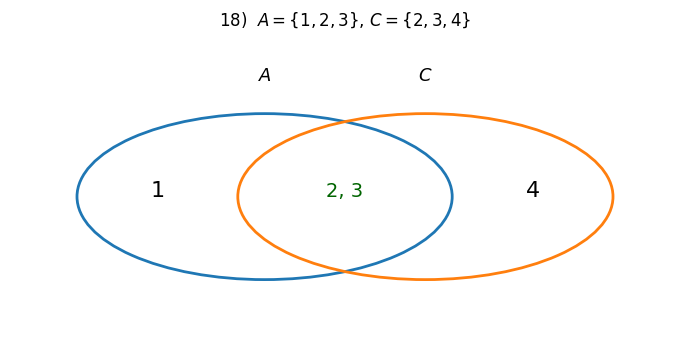

In [18]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# --- 18)  sets A = {1,2,3}, C = {2,3,4} ---
Aset, Cset = {1, 2, 3}, {2, 3, 4}
print("18)  A =", Aset, " C =", Cset)
print("     A∩C =", Aset & Cset, " A∪C =", Aset | Cset, " A\\C =", Aset - Cset)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
ax.add_patch(Circle((0.38, 0.45), 0.28, fill=False, lw=2, ec="C0"))
ax.add_patch(Circle((0.62, 0.45), 0.28, fill=False, lw=2, ec="C1"))
ax.text(0.22, 0.45, "1", fontsize=16, ha="center")
ax.text(0.50, 0.45, "2, 3", fontsize=14, ha="center", color="darkgreen")
ax.text(0.78, 0.45, "4", fontsize=16, ha="center")
ax.text(0.38, 0.84, r"$A$", ha="center", fontsize=13)
ax.text(0.62, 0.84, r"$C$", ha="center", fontsize=13)
ax.set_title(r"18)  $A=\{1,2,3\}$, $C=\{2,3,4\}$")
plt.tight_layout()
plt.show()


### 19) $I_m$
**Identity matrix** of size $m \times m$: ones on the main diagonal, zeros elsewhere.

**Math example:** $I_3 = \begin{bmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}$. For any $\mathbf{v} \in \mathbb{R}^3$, $I_3 \mathbf{v} = \mathbf{v}$.

**Visualize:** heatmap of $I_3$.


I_3 =
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


Is I_3.v = v? True


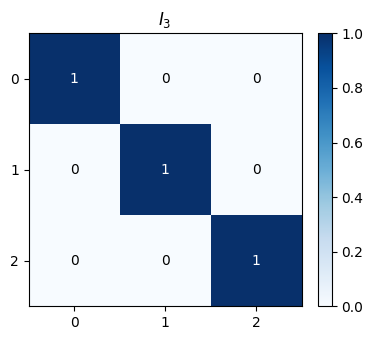

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# --- 19)  I_m  (here I_3) ---
I3 = np.eye(3)
v = np.array([1.0, -2.0, 0.5])
print("I_3 =\n", I3)
print("\n")
print("Is I_3.v = v?", np.allclose(I3 @ v, v)) #I_3.V gives V

fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(I3, cmap="Blues", vmin=0, vmax=1)
for r in range(3):
    for c in range(3):
        ax.text(c, r, str(int(I3[r, c])), ha="center", va="center", color="w" if I3[r, c] > 0.5 else "k")
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_title(r"$I_3$")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()


### 20) $0_{m,n}$
**Zero matrix** of shape $m \times n$ (all entries zero). Some texts write $\mathbf{0}_{m,n}$ for the matrix.

**Math example:** $0_{2,3} = \begin{bmatrix} 0 & 0 & 0 \\ 0 & 0 & 0 \end{bmatrix}$. For any $A \in \mathbb{R}^{3 \times 4}$, $0_{2,3} A = 0_{2,4}$ (whenever the product is defined).

**Visualize:** heatmap of $0_{2,3}$.


0_{2,3} =
 [[0. 0. 0.]
 [0. 0. 0.]]


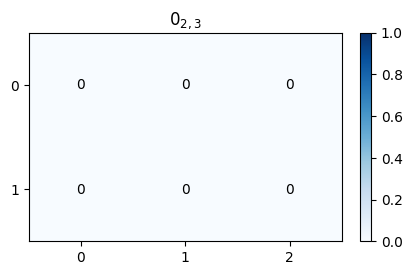

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# --- 20)  0_{m,n}  (here 0_{2,3}) ---
zero_23 = np.zeros((2, 3))
print("0_{2,3} =\n", zero_23)

fig, ax = plt.subplots(figsize=(4.5, 2.8))
im = ax.imshow(zero_23, cmap="Blues", vmin=0, vmax=1)
for r in range(2):
    for c in range(3):
        ax.text(c, r, "0", ha="center", va="center", color="k")
ax.set_xticks(range(3))
ax.set_yticks(range(2))
ax.set_title(r"$0_{2,3}$")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()


### 21) $1_{m,n}$
**Matrix of ones** of shape $m \times n$ (every entry equal to $1$).

**Math example:** $1_{2,2} = \begin{bmatrix} 1 & 1 \\ 1 & 1 \end{bmatrix}$. If $\mathbf{1} = (1,1)^{\top}$, then $1_{2,2} = \mathbf{1} \mathbf{1}^{\top}$ (outer product).

**Visualize:** column $\mathbf{1}$, row $\mathbf{1}^{\top}$, heatmap of $\mathbf{1}\mathbf{1}^{\top}$, and a separate heatmap for the symbol $1_{2,2}$ (the same $2\times 2$ all-ones matrix).


1_{2,2} =
 [[1. 1.]
 [1. 1.]]


Is 1_{2,2} == 11^T ? True


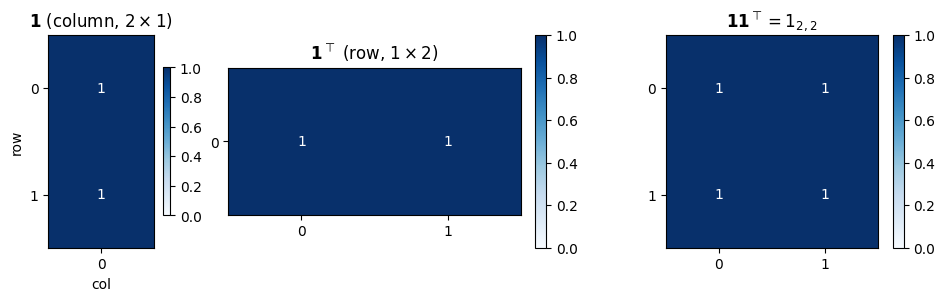

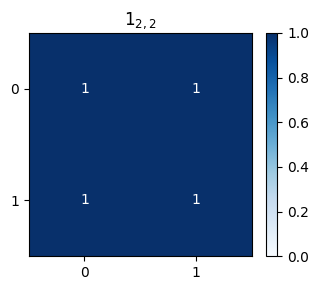

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# --- 21)  1_{m,n}  (here 1_{2,2} = 11^T) ---
ones_22 = np.ones((2, 2))
one = np.array([[1.0], [1.0]])
print("1_{2,2} =\n", ones_22)
print("\n")
print("Is 1_{2,2} == 11^T ?", np.allclose(ones_22, one @ one.T))

# Here 11^T means column 1 times row 1^T (outer product)

outer = one @ one.T

def annotate_matrix(ax, mat, light_text="w"):
    h, w = mat.shape
    for r in range(h):
        for c in range(w):
            ax.text(c, r, str(int(mat[r, c])), ha="center", va="center", color=light_text)


fig, axes = plt.subplots(
    1,
    3,
    figsize=(9.5, 2.9),
    constrained_layout=True,
    gridspec_kw={"width_ratios": [0.55, 1.0, 1.0]},
)

im0 = axes[0].imshow(one, cmap="Blues", vmin=0, vmax=1, aspect="equal")
annotate_matrix(axes[0], one)
axes[0].set_xticks([0])
axes[0].set_yticks(range(2))
axes[0].set_xlabel("col")
axes[0].set_ylabel("row")
axes[0].set_title(r"$\mathbf{1}$ (column, $2\times 1$)")

im1 = axes[1].imshow(one.T, cmap="Blues", vmin=0, vmax=1, aspect="equal")
annotate_matrix(axes[1], one.T)
axes[1].set_xticks(range(2))
axes[1].set_yticks([0])
axes[1].set_title(r"$\mathbf{1}^{\top}$ (row, $1\times 2$)")

im2 = axes[2].imshow(outer, cmap="Blues", vmin=0, vmax=1, aspect="equal")
annotate_matrix(axes[2], outer)
axes[2].set_xticks(range(2))
axes[2].set_yticks(range(2))
axes[2].set_title(r"$\mathbf{1}\mathbf{1}^{\top} = 1_{2,2}$")

for ax, im in zip(axes, (im0, im1, im2)):
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.show()

# Same matrix as 11^T, drawn alone under the name 1_{2,2}
fig, ax = plt.subplots(figsize=(3.5, 3))
im = ax.imshow(ones_22, cmap="Blues", vmin=0, vmax=1)
annotate_matrix(ax, ones_22)
ax.set_xticks(range(2))
ax.set_yticks(range(2))
ax.set_title(r"$1_{2,2}$")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()


### 22) $e_i$
The $i$-th **canonical** (standard basis) vector: a single $1$ in coordinate $i$ and zeros elsewhere (in $\mathbb{R}^m$ when $1 \le i \le m$).

**Math example:** In $\mathbb{R}^4$, $e_3 = (0, 0, 1, 0)^{\top}$. Any $\mathbf{x} = (x_1, x_2, x_3, x_4)^{\top}$ satisfies $\mathbf{x} = \sum_{i=1}^4 x_i e_i$.

**Visualize:** bar chart of the entries of $e_3$ in $\mathbb{R}^4$.

![Example figure](e_i.png)

e_3 = [0. 0. 1. 0.]
Is Σ x_i e_i = x ? True


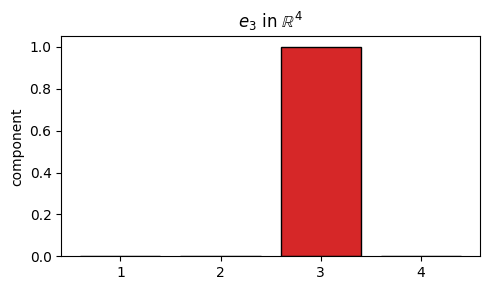

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# --- 22)  e_i  (here e_3 in R^4) ---
e3_R4 = np.eye(4)[2]
x_vec = np.array([1.0, 2.0, 3.0, 4.0])
recon = sum(x_vec[i] * np.eye(4)[i] for i in range(4))
print("e_3 =", e3_R4)
#x_vec.e_i gives x_vec's ith value
#x_vec = [1,2,3,4] , e_3[0,0,1,0]. So, x_vec.e_3=3

print("Is Σ x_i e_i = x ?", np.allclose(recon, x_vec))

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(np.arange(4), e3_R4, color="C3", edgecolor="k")
ax.set_xticks(np.arange(4))
ax.set_xticklabels(["1", "2", "3", "4"])
ax.set_title(r"$e_3$ in $\mathbb{R}^4$")
ax.set_ylabel("component")
plt.tight_layout()
plt.show()


### 23) $\dim$
$\dim V$ is the **dimension** of vector space $V$ [Generally how many component it has ]
dimension of matrix on the other hand means how many rows and columns it has

**Math example:** $\dim(\mathbb{R}^3) = 3$. 

If $W = \operatorname{span}\{(1,0,0)^{\top}, (0,1,0)^{\top}\} \subset \mathbb{R}^3$, then $\dim W = 2$.

![Example figure](dim1.png)

**Visualize:** $3$D scatter: the plane $z=0$ (a $2$D subspace $W$) vs a point off the plane (needs three coordinates — illustrates $\dim \mathbb{R}^3 = 3$).


dim R^3 = 3 (three coordinates)
dim W = 2 (basis for z=0 plane)


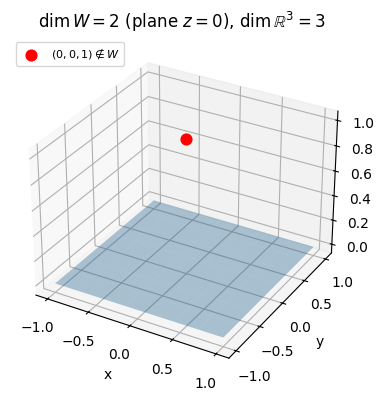

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# dim:  W = xy-plane in R^3 has dim 2; ambient dim 3
basis_W = np.array([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0]])
print("dim R^3 = 3 (three coordinates)")
print("dim W =", np.linalg.matrix_rank(basis_W), "(basis for z=0 plane)")

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(projection="3d")
xg, yg = np.meshgrid(np.linspace(-1, 1, 8), np.linspace(-1, 1, 8))
zg = np.zeros_like(xg)
ax.plot_surface(xg, yg, zg, alpha=0.35, color="C0")
ax.scatter([0], [0], [1], color="red", s=60, label=r"$(0,0,1) \notin W$")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title(r"$\dim W=2$ (plane $z=0$), $\dim\mathbb{R}^3=3$")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


Here the blue square means the xy plane which refers to W (cz W was formed with (1,0,0)&(0,1,0) which in together covers (x,y,0)= x.(1,0,0)+y(0,1,0)). For example, (3,4,0) is within W, (1,2,0) is within W.

But (1,2,1) or, (x,y,z) is not within W.
So, W has 2 variables and thus dimension 2

Here the red dot point (0,0,1) has 3 variables (x,y,z) and thus dimension 3. So, it is not within W. It is outside the blue square plane. Although the x & y points are inactive here, but z is active. So, it needs 3 variables to specify the point (0,0,1) and thus dimension 3.

### 24) $\operatorname{rk}(A)$
$\operatorname{rk}(A)$ is the **rank** of matrix $A$ (dimension of the column space; equals the number of pivots in RREF).

**Math example:** $A = \begin{bmatrix} 1 & 2 \\ 2 & 4 \end{bmatrix}$ has $\operatorname{rk}(A) = 1$ because the second row is $2$ times the first. But $B = \begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix}$ has $\operatorname{rk}(B) = 2$.

Rank means how many independent directions the columns of the matrix span.
Here, Vector [1 2] is drawn in blue. Vector [2 4] is the double of [1 2] which again refers to the same line. So, rank 1

but [1 2] and [3 4] are different vectors. Thus referring to the independent 2 directions.So, rank is 2.


**Visualize:** column vectors of $A$ and $B$ in the plane; rank $1$ = one line, rank $2$ = full parallelogram.




rk(A) = 1  rk(B) = 2


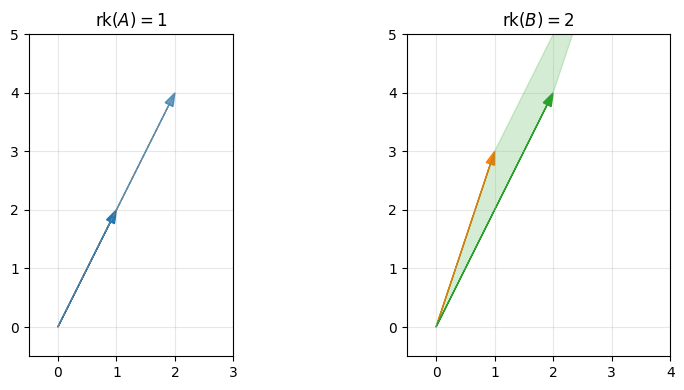

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# --- 24)  rk(A) ---
A_rk = np.array([[1.0, 2.0], [2.0, 4.0]])
B_rk = np.array([[1.0, 2.0], [3.0, 4.0]])
rA, rB = np.linalg.matrix_rank(A_rk), np.linalg.matrix_rank(B_rk)
print("rk(A) =", rA, " rk(B) =", rB)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))
o = np.array([0.0, 0.0])
c1, c2 = A_rk[:, 0], A_rk[:, 1]
ax1.arrow(*o, *c1, head_width=0.15, length_includes_head=True, color="C0")
ax1.arrow(*o, *c2, head_width=0.15, length_includes_head=True, color="C0", alpha=0.7)
ax1.plot([0, c2[0]], [0, c2[1]], "--", color="gray", lw=0.8)
ax1.set_aspect("equal")
ax1.set_xlim(-0.5, 3)
ax1.set_ylim(-0.5, 5)
ax1.grid(True, alpha=0.3)
ax1.set_title(r"$\operatorname{rk}(A)=1$")

d1, d2 = B_rk[:, 0], B_rk[:, 1]
ax2.arrow(*o, *d1, head_width=0.15, length_includes_head=True, color="C1")
ax2.arrow(*o, *d2, head_width=0.15, length_includes_head=True, color="C2")
poly = np.vstack([o, d1, d1 + d2, d2, o])
ax2.fill(poly[:, 0], poly[:, 1], alpha=0.2, color="C2")
ax2.set_aspect("equal")
ax2.set_xlim(-0.5, 4)
ax2.set_ylim(-0.5, 5)
ax2.grid(True, alpha=0.3)
ax2.set_title(r"$\operatorname{rk}(B)=2$")
plt.tight_layout()
plt.show()


Here, Vector [1 2] is drawn in blue. Vector [2 4] is the double of [1 2] which again refers to the same line. So, rank 1

but [1 2] and [3 4] are different vectors. Thus referring to the independent 2 directions.So, rank is 2.



## 25. Image Im(Phi)

**Important:** In linear algebra, **image** does not mean a picture.  
It means the set of **all possible outputs** of a transformation.

For a linear map `Phi: V -> W`, the image is:

`Im(Phi) = all Phi(v) values, where v comes from V`

So the image answers this question:

> After applying the transformation, where can the output land?

---

If the map is written as `Phi(x) = A x`, then every output is made by combining the columns of `A`.

So:

`Im(Phi) = column space of A`

Another way to say the same thing:

`image of the map = all linear combinations of the columns of the matrix`

---

### Example: projection onto the x-axis

Let:

`A = [[1, 0], [0, 0]]`

This matrix sends any point `(x, y)` to `(x, 0)`.

Examples:

- `(3, 5) -> (3, 0)`
- `(-2, 7) -> (-2, 0)`
- `(0, 100) -> (0, 0)`

No matter what `y` is, the output always has second coordinate `0`.

So every output lands on the **x-axis**.

Therefore:

`Im(Phi) = all points of the form (x, 0)`

That is the same as:

`Im(Phi) = span{(1, 0)}`

This map takes inputs from `R^2`, but its image is only a **1-dimensional line** inside `R^2`.

---

### Visual idea

- For a general `2 x 2` matrix, the unit square can become a **parallelogram**.
- For the projection matrix `[[1, 0], [0, 0]]`, the square collapses into a **line segment on the x-axis**.

That line is the image of the transformation.


Im(Φ) = all reachable outputs = Col(A)
General A columns: [2. 1.] and [0.5 1.5] -> parallelogram
Projection P maps [x, y] -> [x, 0], so Im(P) = span{(1, 0)}


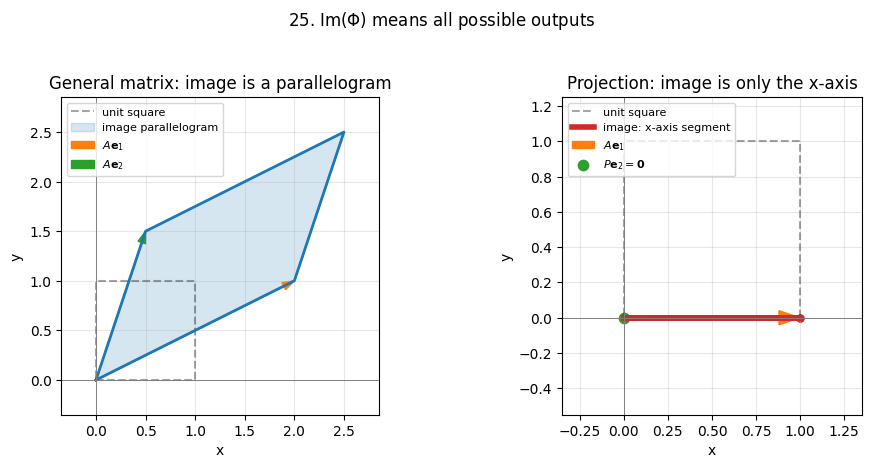

In [25]:
import matplotlib.pyplot as plt
import numpy as np

square = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]]).T

A_general = np.array([[2.0, 0.5], [1.0, 1.5]])
P_projection = np.array([[1.0, 0.0], [0.0, 0.0]])

print("Im(Φ) = all reachable outputs = Col(A)")
print("General A columns:", A_general[:, 0], "and", A_general[:, 1], "-> parallelogram")
print("Projection P maps [x, y] -> [x, 0], so Im(P) = span{(1, 0)}")

def setup_axes(ax, xlim, ylim):
    ax.set_aspect("equal")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.axhline(0, color="gray", lw=0.7)
    ax.axvline(0, color="gray", lw=0.7)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

def draw_map(ax, A, title, xlim, ylim, collapsed=False):
    mapped = A @ square
    c0, c1 = A[:, 0], A[:, 1]

    ax.plot(square[0], square[1], "k--", alpha=0.35, label="unit square")
    if collapsed:
        ax.plot(mapped[0], mapped[1], color="C3", lw=4, label="image: x-axis segment")
        ax.scatter(mapped[0], mapped[1], color="C3", s=25)
    else:
        ax.fill(mapped[0], mapped[1], color="C0", alpha=0.18, label="image parallelogram")
        ax.plot(mapped[0], mapped[1], color="C0", lw=2)

    ax.arrow(0, 0, c0[0], c0[1], head_width=0.08, length_includes_head=True, color="C1", label=r"$A\mathbf{e}_1$")
    if np.linalg.norm(c1) > 0:
        ax.arrow(0, 0, c1[0], c1[1], head_width=0.08, length_includes_head=True, color="C2", label=r"$A\mathbf{e}_2$")
    else:
        ax.scatter([0], [0], color="C2", s=55, label=r"$P\mathbf{e}_2=\mathbf{0}$")

    setup_axes(ax, xlim, ylim)
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))

draw_map(
    ax1,
    A_general,
    "General matrix: image is a parallelogram",
    xlim=(-0.35, 2.85),
    ylim=(-0.35, 2.85),
)

draw_map(
    ax2,
    P_projection,
    "Projection: image is only the x-axis",
    xlim=(-0.35, 1.35),
    ylim=(-0.55, 1.25),
    collapsed=True,
)

plt.suptitle(r"25. $\operatorname{Im}(\Phi)$ means all possible outputs", y=1.03)
plt.tight_layout()
plt.show()


This graph shows the **image** of a matrix transformation: all possible outputs after applying the matrix. On the left, a general matrix sends the unit square to a **parallelogram**, because the two basis directions `e1` and `e2` become two independent column vectors. On the right, the projection matrix sends every point `(x, y)` to `(x, 0)`, so the whole square collapses onto the **x-axis**. Therefore, the image of the projection is only the line `span{(1, 0)}`, a **1-dimensional output** inside `R^2`.


## 26. Kernel ker(Phi)

The **kernel** is the set of all input vectors that become **zero** after applying the transformation.

For a map `Phi`, the kernel means:

`ker(Phi) = all inputs v where Phi(v) = 0`

If the map is written as `Phi(x) = A x`, then:

`ker(Phi) = all x values where A x = 0`

So the kernel answers this question:

> Which input directions get completely flattened to zero?

---

### Example

Let:

`A = [[1, 2], [2, 4]]`

This matrix has rank `1`, because the second row is just `2` times the first row.

Now check the vector `(2, -1)`:

- First output: `1*2 + 2*(-1) = 0`
- Second output: `2*2 + 4*(-1) = 0`

So:

`A(2, -1) = (0, 0)`

Every multiple of `(2, -1)` also goes to zero, for example:

- `(-2, 1) -> (0, 0)`
- `(2, -1) -> (0, 0)`
- `(4, -2) -> (0, 0)`

Therefore:

`ker(Phi) = span{(2, -1)}`

---

### Visual idea

In `R^2`, the kernel is a **line through the origin**. Every point on that line is sent to `(0, 0)`.

So the image tells us **where outputs can land**, while the kernel tells us **which inputs disappear**.


26) rank(A) = 1
A @ (2, -1) = [0. 0.]
All points on the blue kernel line map to (0, 0).
Example not in kernel: A @ (1, 0) = [1. 2.]


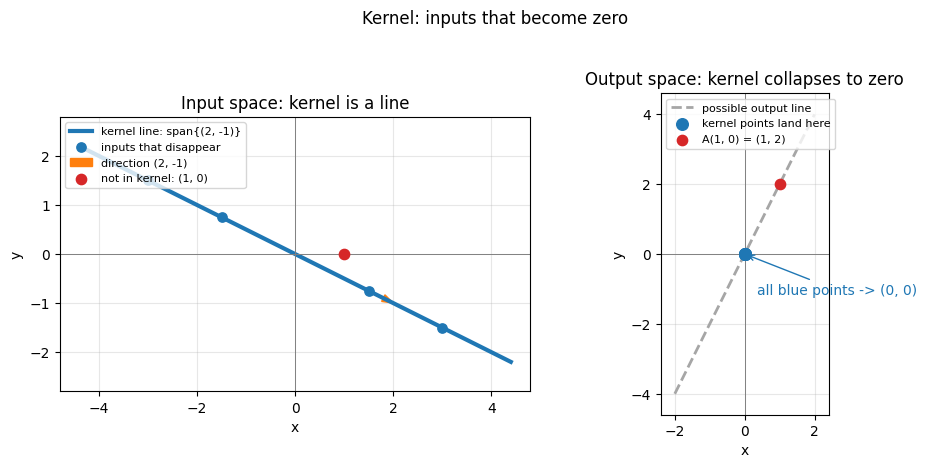

In [26]:
import matplotlib.pyplot as plt
import numpy as np

A = np.array([[1.0, 2.0], [2.0, 4.0]])

# Kernel direction: every multiple of (2, -1) maps to (0, 0).
kernel_dir = np.array([2.0, -1.0])
t = np.linspace(-2.2, 2.2, 150)
kernel_line = np.outer(t, kernel_dir)

sample_t = np.array([-1.5, -0.75, 0.75, 1.5])
kernel_points = np.outer(sample_t, kernel_dir)
mapped_kernel_points = kernel_points @ A.T

non_kernel_point = np.array([1.0, 0.0])
mapped_non_kernel = A @ non_kernel_point

print("26) rank(A) =", np.linalg.matrix_rank(A))
print("A @ (2, -1) =", A @ kernel_dir)
print("All points on the blue kernel line map to (0, 0).")
print("Example not in kernel: A @ (1, 0) =", mapped_non_kernel)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))

# Left: input/domain space.
ax1.plot(kernel_line[:, 0], kernel_line[:, 1], color="C0", lw=3, label="kernel line: span{(2, -1)}")
ax1.scatter(kernel_points[:, 0], kernel_points[:, 1], color="C0", s=45, zorder=3, label="inputs that disappear")
ax1.arrow(0, 0, kernel_dir[0], kernel_dir[1], head_width=0.15, length_includes_head=True, color="C1", label="direction (2, -1)")
ax1.scatter([non_kernel_point[0]], [non_kernel_point[1]], color="C3", s=55, zorder=4, label="not in kernel: (1, 0)")
ax1.set_title("Input space: kernel is a line")
ax1.set_xlim(-4.8, 4.8)
ax1.set_ylim(-2.8, 2.8)

# Right: output space.
image_line_t = np.linspace(-2, 2, 100)
image_line = np.outer(image_line_t, np.array([1.0, 2.0]))
ax2.plot(image_line[:, 0], image_line[:, 1], color="0.65", lw=2, ls="--", label="possible output line")
ax2.scatter(mapped_kernel_points[:, 0], mapped_kernel_points[:, 1], color="C0", s=70, zorder=3, label="kernel points land here")
ax2.scatter([mapped_non_kernel[0]], [mapped_non_kernel[1]], color="C3", s=55, zorder=4, label="A(1, 0) = (1, 2)")
ax2.annotate("all blue points -> (0, 0)", xy=(0, 0), xytext=(0.35, -1.15), arrowprops=dict(arrowstyle="->", color="C0"), color="C0")
ax2.set_title("Output space: kernel collapses to zero")
ax2.set_xlim(-2.4, 2.4)
ax2.set_ylim(-4.6, 4.6)

for ax in (ax1, ax2):
    ax.set_aspect("equal")
    ax.axhline(0, color="gray", lw=0.7)
    ax.axvline(0, color="gray", lw=0.7)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(loc="upper left", fontsize=8)

plt.suptitle("Kernel: inputs that become zero", y=1.03)
plt.tight_layout()
plt.show()


This graph shows the **kernel** of the matrix transformation. On the left, the blue line is `span{(2, -1)}`: every point on this line is an input that gets sent to zero. The orange arrow shows the kernel direction `(2, -1)`, while the red point `(1, 0)` is not in the kernel. On the right, all blue kernel points collapse to `(0, 0)`, but the red point maps to `(1, 2)`. So the kernel tells us **which input directions disappear** after applying the matrix.


## Extended Visuals, Explanation, and Theory

From here onward, each notation section has a clearer learning pattern:

**Notation:** what the symbol means.

**Theory:** why the symbol matters and how it behaves.

**Math example:** a small concrete calculation.

**Visualize:** a runnable plot or diagram.

**What the visual shows:** plain-language interpretation after the figure.


## 27. Span $\operatorname{span}\{\mathbf{b}_1\}$

**Notation:** $\operatorname{span}\{\mathbf{b}_1\}$ is the set of **all scalar multiples** $\alpha \mathbf{b}_1$ (a line through the origin if $\mathbf{b}_1 \neq \mathbf{0}$). For several vectors, $\operatorname{span}\{\mathbf{b}_1,\ldots,\mathbf{b}_k\}$ is all linear combinations.


**Theory:** A span is the smallest vector subspace that contains the listed vectors. One nonzero vector in $\mathbb{R}^2$ spans a line through the origin; two independent vectors span a plane; dependent vectors do not add a new direction.

**Math example:** $\mathbf{b}_1 = (2,1)^{\top}$ gives $\operatorname{span}\{\mathbf{b}_1\} = \{(2t,t)^{\top} : t \in \mathbb{R}\}$.


**Best example:** Compare one vector, which spans only a line, with two independent vectors, which can reach a whole 2D grid of points.

**Visualize:** the line through $\mathbf{b}_1$ and the origin.


27) span{b1}: every point is t*b1, a line through the origin.
    span{b1,b2}: because det([b1 b2]) = 5.000000000000001 the two vectors span R^2.


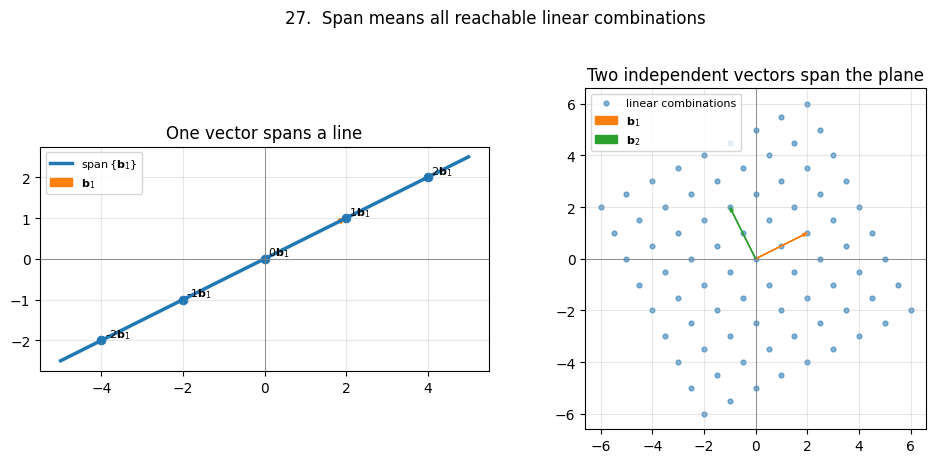

In [27]:
import matplotlib.pyplot as plt
import numpy as np

b1 = np.array([2.0, 1.0])
b2 = np.array([-1.0, 2.0])
t = np.linspace(-2.5, 2.5, 120)
line = np.outer(t, b1)

a = np.linspace(-2, 2, 9)
b = np.linspace(-2, 2, 9)
Agrid, Bgrid = np.meshgrid(a, b)
plane_pts = Agrid[..., None] * b1 + Bgrid[..., None] * b2

print("27) span{b1}: every point is t*b1, a line through the origin.")
print("    span{b1,b2}: because det([b1 b2]) =", np.linalg.det(np.column_stack([b1, b2])), "the two vectors span R^2.")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].plot(line[:, 0], line[:, 1], "C0", lw=2.5, label=r"$\operatorname{span}\{\mathbf{b}_1\}$")
for k in [-2, -1, 0, 1, 2]:
    p = k * b1
    axes[0].scatter(p[0], p[1], color="C0", s=35)
    axes[0].text(p[0] + 0.08, p[1] + 0.08, str(k) + r"$\mathbf{b}_1$", fontsize=8)
axes[0].arrow(0, 0, b1[0], b1[1], head_width=0.12, length_includes_head=True, color="C1", label=r"$\mathbf{b}_1$")
axes[0].set_title("One vector spans a line")

axes[1].scatter(plane_pts[..., 0], plane_pts[..., 1], s=12, alpha=0.55, color="C0", label="linear combinations")
axes[1].arrow(0, 0, b1[0], b1[1], head_width=0.12, length_includes_head=True, color="C1", label=r"$\mathbf{b}_1$")
axes[1].arrow(0, 0, b2[0], b2[1], head_width=0.12, length_includes_head=True, color="C2", label=r"$\mathbf{b}_2$")
axes[1].set_title("Two independent vectors span the plane")

for ax in axes:
    ax.set_aspect("equal")
    ax.axhline(0, color="gray", lw=0.6)
    ax.axvline(0, color="gray", lw=0.6)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle(r"27.  Span means all reachable linear combinations", y=1.02)
plt.tight_layout()
plt.show()


**What the visual shows:** The left panel shows that all multiples of one vector lie on one line. The right panel shows that two independent vectors create a grid of reachable linear combinations, which is the geometric meaning of spanning a plane.


## 28. Trace $\operatorname{tr}(A)$

**Notation:** $\operatorname{tr}(A)$ is the **sum of the diagonal entries** of a square matrix $A$.


**Theory:** The trace is invariant under a change of basis, equals the sum of eigenvalues counted with multiplicity, and often appears in optimization because $\operatorname{tr}(\mathbf{x}\mathbf{x}^{\top})=\|\mathbf{x}\|_2^2$.

**Math example:** $\operatorname{tr}\begin{bmatrix} 1 & 5 \\ 3 & 2 \end{bmatrix} = 1 + 2 = 3$. Also $\operatorname{tr}(AB) = \operatorname{tr}(BA)$ when shapes match.


**Best example:** Use the same linear operator in two different bases and check that the trace stays the same.

**Visualize:** matrix heatmap with the diagonal highlighted.


28) diag(A) = [ 2.  3. -1.] trace(A) = 4.0
    trace(P^{-1}AP) = 4.0 (same trace after change of basis)


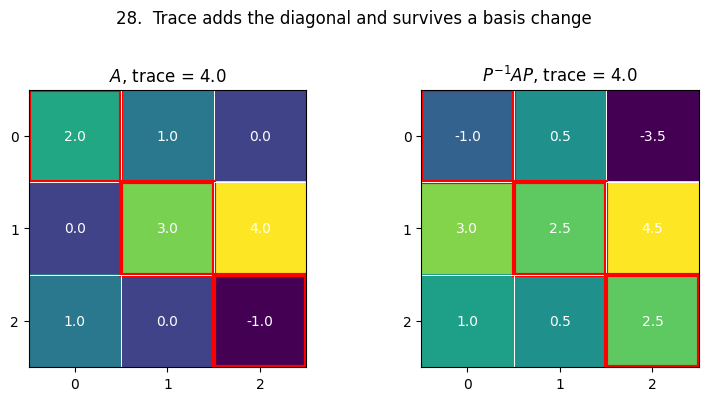

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

A = np.array([[2.0, 1.0, 0.0], [0.0, 3.0, 4.0], [1.0, 0.0, -1.0]])
P = np.array([[1.0, 1.0, 0.0], [0.0, 1.0, 1.0], [1.0, 0.0, 1.0]])
B = np.linalg.inv(P) @ A @ P

print("28) diag(A) =", np.diag(A), "trace(A) =", np.trace(A))
print("    trace(P^{-1}AP) =", np.trace(B), "(same trace after change of basis)")

fig, axes = plt.subplots(1, 2, figsize=(8, 3.8))
for ax, M, title in [(axes[0], A, r"$A$"), (axes[1], B, r"$P^{-1}AP$")]:
    im = ax.imshow(M, cmap="viridis")
    for r in range(M.shape[0]):
        for c in range(M.shape[1]):
            is_diag = r == c
            ax.add_patch(Rectangle((c - 0.5, r - 0.5), 1, 1, fill=False, ec="red" if is_diag else "white", lw=3 if is_diag else 0.7))
            ax.text(c, r, f"{M[r, c]:.1f}", ha="center", va="center", color="white", fontsize=10)
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_title(rf"{title}, trace = {np.trace(M):.1f}")

plt.suptitle(r"28.  Trace adds the diagonal and survives a basis change", y=1.03)
plt.tight_layout()
plt.show()


**What the visual shows:** The red diagonal cells are the only entries used by trace. The second heatmap represents the same operator after a change of basis; the diagonal entries change, but their sum stays the same.


## 29. Determinant $\det(A)$; $|A|$ for matrices

**Notation:** $\det(A)$ measures **oriented volume** scaling: for $A \in \mathbb{R}^{n \times n}$, $|\det(A)|$ is how $A$ scales $n$-dimensional volume. Some authors write **$|A|$** for $|\det(A)|$ when $A$ is square (context: matrix, not a vector).


**Theory:** In 2D, $|\det(A)|$ is area scaling; in 3D it is volume scaling. A zero determinant means the transformation collapses space into a lower-dimensional object, so $A$ is not invertible. The sign records orientation.

**Math example:** $A = \begin{bmatrix} a & b \\ c & d \end{bmatrix}$ has $\det(A) = ad - bc$ = area of parallelogram spanned by columns (sign = orientation).


**Best example:** Compare positive determinant, negative determinant, and zero determinant transformations of the unit square.

**Visualize:** parallelogram from the two columns in $\mathbb{R}^2$; area $= |\det(A)|$.


29) determinant examples: positive preserves orientation, negative flips, zero collapses area.


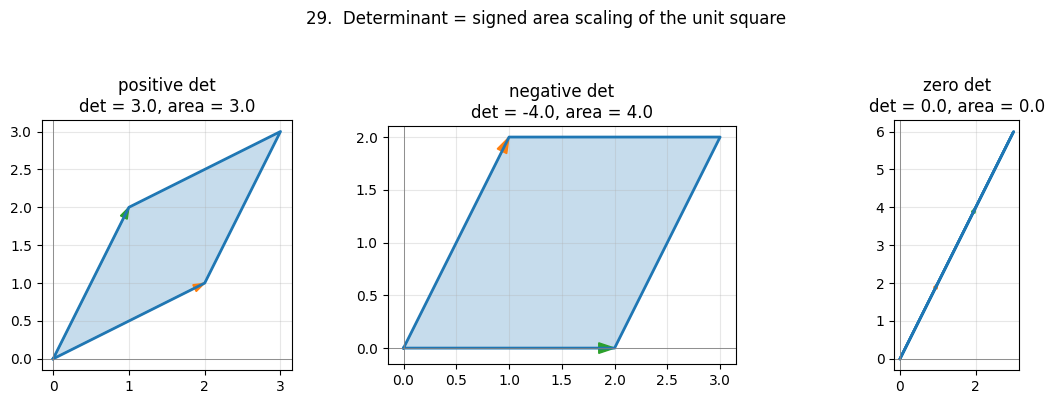

In [29]:
import matplotlib.pyplot as plt
import numpy as np

cases = [
    ("positive det", np.array([[2.0, 1.0], [1.0, 2.0]])),
    ("negative det", np.array([[1.0, 2.0], [2.0, 0.0]])),
    ("zero det", np.array([[1.0, 2.0], [2.0, 4.0]])),
]
unit = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]], dtype=float).T

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, (name, A) in zip(axes, cases):
    image = A @ unit
    det = np.linalg.det(A)
    ax.fill(image[0], image[1], alpha=0.25, color="C0")
    ax.plot(image[0], image[1], "C0", lw=2)
    ax.arrow(0, 0, A[0, 0], A[1, 0], head_width=0.1, length_includes_head=True, color="C1", label="col 1")
    ax.arrow(0, 0, A[0, 1], A[1, 1], head_width=0.1, length_includes_head=True, color="C2", label="col 2")
    ax.axhline(0, color="gray", lw=0.6)
    ax.axvline(0, color="gray", lw=0.6)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.set_title(f"{name}\ndet = {det:.1f}, area = {abs(det):.1f}")

print("29) determinant examples: positive preserves orientation, negative flips, zero collapses area.")
plt.suptitle(r"29.  Determinant = signed area scaling of the unit square", y=1.05)
plt.tight_layout()
plt.show()


**What the visual shows:** A positive determinant preserves orientation, a negative determinant flips orientation, and a zero determinant collapses area to a line. The shaded transformed square makes area scaling visible.


## 30. Absolute value $| \cdot |$ (scalar context)

**Notation:** For a real number $x$, $|x|$ is **distance from $0$** on the line. This is **not** the determinant: the same symbol $|\cdot|$ is reused—**read the type of object inside** (scalar vs square matrix).


**Theory:** Absolute value removes sign but keeps magnitude. It also defines distance on the real line: the distance between $x$ and $a$ is $|x-a|$. In optimization, absolute value creates a sharp corner at $0$, which is why $\ell_1$ losses behave differently from squared losses.

**Math example:** $|-3| = 3$, $|x-1|$ is distance from $x$ to $1$.


**Best example:** Show absolute value both as a V-shaped function and as distance on the number line.

**Visualize:** graph of $y = |x|$.


30) |-3| = 3 and |3| = 3 because both are distance 3 from zero.


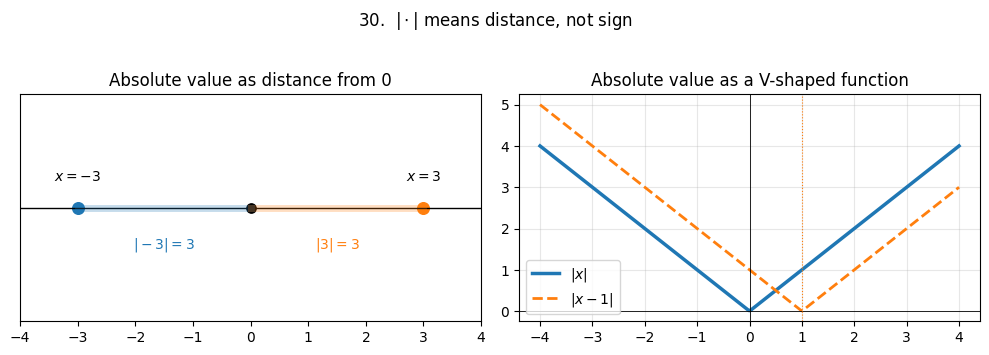

In [30]:
import matplotlib.pyplot as plt
import numpy as np

xs = np.linspace(-4, 4, 300)
points = [-3, 3]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))

axes[0].axhline(0, color="k", lw=1)
for p, color in zip(points, ["C0", "C1"]):
    axes[0].scatter([p], [0], s=70, color=color)
    axes[0].plot([0, p], [0, 0], color=color, lw=5, alpha=0.25)
    axes[0].text(p, 0.12, rf"$x={p}$", ha="center")
    axes[0].text(p / 2, -0.18, rf"$|{p}|={abs(p)}$", ha="center", color=color)
axes[0].scatter([0], [0], color="black", s=45)
axes[0].set_xlim(-4, 4)
axes[0].set_ylim(-0.5, 0.5)
axes[0].set_yticks([])
axes[0].set_title("Absolute value as distance from 0")

axes[1].plot(xs, np.abs(xs), "C0", lw=2.5, label=r"$|x|$")
axes[1].plot(xs, np.abs(xs - 1), "C1", lw=2, ls="--", label=r"$|x-1|$")
axes[1].axhline(0, color="k", lw=0.6)
axes[1].axvline(0, color="k", lw=0.6)
axes[1].axvline(1, color="C1", lw=0.8, ls=":")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_title("Absolute value as a V-shaped function")

print("30) |-3| =", abs(-3), "and |3| =", abs(3), "because both are distance 3 from zero.")
plt.suptitle(r"30.  $|\cdot|$ means distance, not sign", y=1.03)
plt.tight_layout()
plt.show()


**What the visual shows:** The number line shows absolute value as distance from zero. The function plot shows the same idea algebraically: negative inputs are folded upward into positive distances.


## 31. Norm $\|\cdot\|$ (Euclidean unless stated)

**Notation:** $\|\mathbf{x}\|$ usually means the **Euclidean** norm $\sqrt{\mathbf{x}^{\top}\mathbf{x}} = \sqrt{\sum_i x_i^2}$. Other norms ($\ell_1$, $\ell_\infty$, etc.) are labeled explicitly.


**Theory:** A norm measures vector length and must be nonnegative, zero only at $\mathbf{0}$, scale with absolute scalar value, and satisfy the triangle inequality. Norms are the backbone of distance, regularization, error measurement, and convergence criteria in ML.

**Math example:** $\|(3,4)^{\top}\| = \sqrt{9+16} = 5$.


**Best example:** Compare Euclidean length with the shapes of the $\ell_1$, $\ell_2$, and $\ell_\infty$ unit balls.

**Visualize:** vector from the origin and a circle/sphere of radius $\|\mathbf{x}\|$.


31) ||(3,4)||_2 = 5.0
    ||(3,4)||_1 = 7.0 ||x||_infty = 4.0


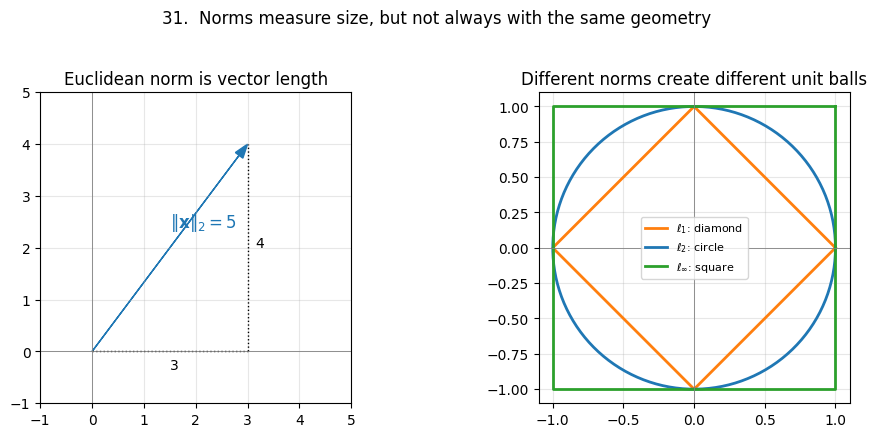

In [31]:
import matplotlib.pyplot as plt
import numpy as np

x = np.array([3.0, 4.0])
theta = np.linspace(0, 2 * np.pi, 400)
circle = np.c_[np.cos(theta), np.sin(theta)]
diamond = np.array([[1, 0], [0, 1], [-1, 0], [0, -1], [1, 0]], dtype=float)
square = np.array([[1, 1], [-1, 1], [-1, -1], [1, -1], [1, 1]], dtype=float)

print("31) ||(3,4)||_2 =", np.linalg.norm(x))
print("    ||(3,4)||_1 =", np.linalg.norm(x, 1), "||x||_infty =", np.linalg.norm(x, np.inf))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
axes[0].arrow(0, 0, x[0], x[1], head_width=0.18, length_includes_head=True, color="C0")
axes[0].plot([x[0], x[0]], [0, x[1]], "k:", lw=1)
axes[0].plot([0, x[0]], [0, 0], "k:", lw=1)
axes[0].text(1.5, -0.35, "3")
axes[0].text(3.15, 2.0, "4")
axes[0].text(1.5, 2.4, r"$\|\mathbf{x}\|_2=5$", color="C0", fontsize=12)
axes[0].set_title("Euclidean norm is vector length")
axes[0].set_aspect("equal")
axes[0].set_xlim(-1, 5)
axes[0].set_ylim(-1, 5)

axes[1].plot(diamond[:, 0], diamond[:, 1], "C1", lw=2, label=r"$\ell_1$: diamond")
axes[1].plot(circle[:, 0], circle[:, 1], "C0", lw=2, label=r"$\ell_2$: circle")
axes[1].plot(square[:, 0], square[:, 1], "C2", lw=2, label=r"$\ell_\infty$: square")
axes[1].set_title("Different norms create different unit balls")
axes[1].set_aspect("equal")
axes[1].legend(fontsize=8)

for ax in axes:
    ax.axhline(0, color="gray", lw=0.6)
    ax.axvline(0, color="gray", lw=0.6)
    ax.grid(True, alpha=0.3)

plt.suptitle(r"31.  Norms measure size, but not always with the same geometry", y=1.03)
plt.tight_layout()
plt.show()


**What the visual shows:** The vector length is one norm example. The unit-ball panel shows that different norms define different shapes of 'distance 1', which is why norm choice changes ML regularization behavior.


## 32. $\lambda$: eigenvalue (and Lagrange multiplier)

**Eigenvalue:** $\lambda$ is an **eigenvalue** of a square matrix $A$ if there is a nonzero $\mathbf{v}$ with $A\mathbf{v} = \lambda \mathbf{v}$.

**Lagrange multipliers:** In constrained optimization, $\lambda$ often denotes **Lagrange multipliers** (same Greek letter, different meaning—**context** tells you which).


**Theory:** Eigenvectors are directions that a matrix does not rotate away from; it only stretches, shrinks, or flips them. Eigenvalues tell the amount of stretch. The same symbol $\lambda$ is also used for Lagrange multipliers, so the surrounding equation tells you the meaning.

**Math example:** $A = \begin{bmatrix} 2 & 1 \\ 1 & 2 \end{bmatrix}$ has eigenvalues $3$ and $1$ with eigenvectors $(1,1)^{\top}$ and $(1,-1)^{\top}$.


**Best example:** Show that eigenvectors stay on their own lines after transformation, while a generic vector changes direction.

**Visualize:** eigenvector directions; $A$ stretches along each by its eigenvalue.


32) eigenvalues: [1. 3.]
    A @ v = [-0.70710678  0.70710678] lambda*v = [-0.70710678  0.70710678]
    A @ v = [2.12132034 2.12132034] lambda*v = [2.12132034 2.12132034]


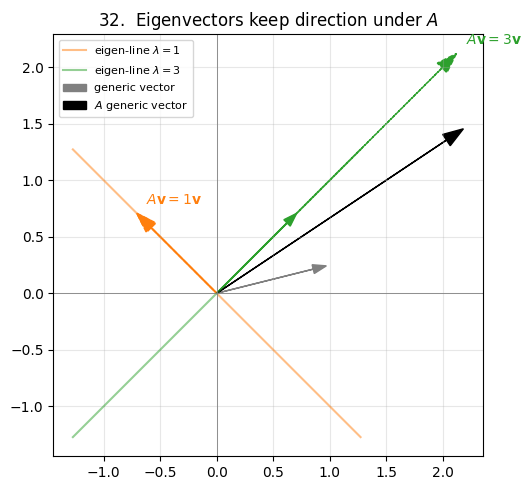

In [32]:
import matplotlib.pyplot as plt
import numpy as np

A = np.array([[2.0, 1.0], [1.0, 2.0]])
w, V = np.linalg.eigh(A)
generic = np.array([1.0, 0.25])
generic = generic / np.linalg.norm(generic)
t = np.linspace(-1.8, 1.8, 100)

print("32) eigenvalues:", w)
for lam, v in zip(w, V.T):
    print("    A @ v =", A @ v, "lambda*v =", lam * v)

fig, ax = plt.subplots(figsize=(6, 5))
colors = ["C1", "C2"]
for lam, v, color in zip(w, V.T, colors):
    ax.plot(t * v[0], t * v[1], color=color, lw=1.5, alpha=0.5, label=rf"eigen-line $\lambda={lam:g}$")
    ax.arrow(0, 0, v[0], v[1], head_width=0.08, length_includes_head=True, color=color)
    Av = A @ v
    ax.arrow(0, 0, Av[0], Av[1], head_width=0.12, length_includes_head=True, color=color, ls="--")
    ax.text(Av[0] + 0.08, Av[1] + 0.08, rf"$A\mathbf{{v}}={lam:g}\mathbf{{v}}$", color=color)

Ag = A @ generic
ax.arrow(0, 0, generic[0], generic[1], head_width=0.08, length_includes_head=True, color="gray", label="generic vector")
ax.arrow(0, 0, Ag[0], Ag[1], head_width=0.12, length_includes_head=True, color="black", label=r"$A$ generic vector")
ax.set_aspect("equal")
ax.axhline(0, color="gray", lw=0.6)
ax.axvline(0, color="gray", lw=0.6)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc="upper left")
ax.set_title(r"32.  Eigenvectors keep direction under $A$")
plt.tight_layout()
plt.show()


**What the visual shows:** Eigenvectors stay on their colored eigen-lines after applying the matrix. The gray generic vector does not stay on its original line, so it is not an eigenvector.


## 33. Eigenspace $E_{\lambda}$

**Notation:** $E_{\lambda} = \{\mathbf{v} : A\mathbf{v} = \lambda \mathbf{v}\} = \ker(A - \lambda I)$ is the **eigenspace** for eigenvalue $\lambda$ (a subspace, including $\mathbf{0}$).


**Theory:** An eigenspace contains every vector that points in an eigen-direction for the same eigenvalue, plus the zero vector. Because $E_\lambda=\ker(A-\lambda I)$, it is a subspace.

**Math example:** For the same $A = \begin{bmatrix} 2 & 1 \\ 1 & 2 \end{bmatrix}$, $E_3 = \operatorname{span}\{(1,1)^{\top}\}$ and $E_1 = \operatorname{span}\{(1,-1)^{\top}\}$.


**Best example:** Plot whole eigenspace lines, not just one eigenvector, and connect them to the kernel of $A-\lambda I$.

**Visualize:** the two eigenspaces as orthogonal lines through the origin.


33) E_3 = kernel(A - 3I) = span{(1,1)}
    E_1 = kernel(A - I) = span{(1,-1)}


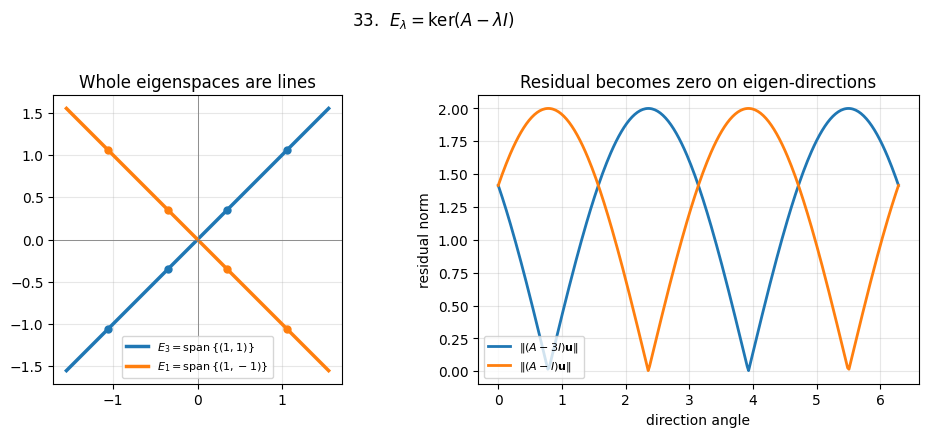

In [33]:
import matplotlib.pyplot as plt
import numpy as np

A = np.array([[2.0, 1.0], [1.0, 2.0]])
v3 = np.array([1.0, 1.0]) / np.sqrt(2)
v1 = np.array([1.0, -1.0]) / np.sqrt(2)
t = np.linspace(-2.2, 2.2, 120)
angles = np.linspace(0, 2 * np.pi, 300)
unit = np.c_[np.cos(angles), np.sin(angles)]
res3 = np.linalg.norm((A - 3 * np.eye(2)) @ unit.T, axis=0)
res1 = np.linalg.norm((A - 1 * np.eye(2)) @ unit.T, axis=0)

print("33) E_3 = kernel(A - 3I) = span{(1,1)}")
print("    E_1 = kernel(A - I) = span{(1,-1)}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
axes[0].plot(t * v3[0], t * v3[1], "C0", lw=2.5, label=r"$E_3=\operatorname{span}\{(1,1)\}$")
axes[0].plot(t * v1[0], t * v1[1], "C1", lw=2.5, label=r"$E_1=\operatorname{span}\{(1,-1)\}$")
for v, color in [(v3, "C0"), (v1, "C1")]:
    for s in [-1.5, -0.5, 0.5, 1.5]:
        p = s * v
        axes[0].scatter(p[0], p[1], color=color, s=25)
axes[0].set_title("Whole eigenspaces are lines")
axes[0].legend(fontsize=8)

axes[1].plot(angles, res3, "C0", lw=2, label=r"$\|(A-3I)\mathbf{u}\|$")
axes[1].plot(angles, res1, "C1", lw=2, label=r"$\|(A-I)\mathbf{u}\|$")
axes[1].set_xlabel("direction angle")
axes[1].set_ylabel("residual norm")
axes[1].set_title("Residual becomes zero on eigen-directions")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

for ax in [axes[0]]:
    ax.set_aspect("equal")
    ax.axhline(0, color="gray", lw=0.6)
    ax.axvline(0, color="gray", lw=0.6)
    ax.grid(True, alpha=0.3)

plt.suptitle(r"33.  $E_\lambda=\ker(A-\lambda I)$", y=1.03)
plt.tight_layout()
plt.show()


**What the visual shows:** Each eigenspace is a whole line of vectors sharing the same stretch factor. The residual plot highlights that $(A-\lambda I)\mathbf{v}$ becomes zero exactly along the matching eigenspace.


## 34. $\boldsymbol{\theta}$ — parameter vector

**Notation:** $\boldsymbol{\theta}$ (bold $\theta$) stacks **learnable parameters** (weights and biases in neural nets, coefficients in regression). Optimization adjusts $\boldsymbol{\theta}$ to reduce a loss.


**Theory:** A model family becomes a specific model only after choosing $\boldsymbol{\theta}$. Training is usually the search for parameter values that minimize a loss, such as $\min_{\boldsymbol{\theta}} J(\boldsymbol{\theta})$.

**Math example:** Linear model $y \approx \mathbf{x}^{\top} \boldsymbol{\theta}$ with $\boldsymbol{\theta} \in \mathbb{R}^d$.


**Best example:** Use a tiny linear regression model so each parameter visibly controls intercept and slope.

**Visualize:** bar chart of a small parameter vector.


34) theta = [intercept, slope] = [1.  0.8]
    model: y_hat = theta_0 + theta_1*x


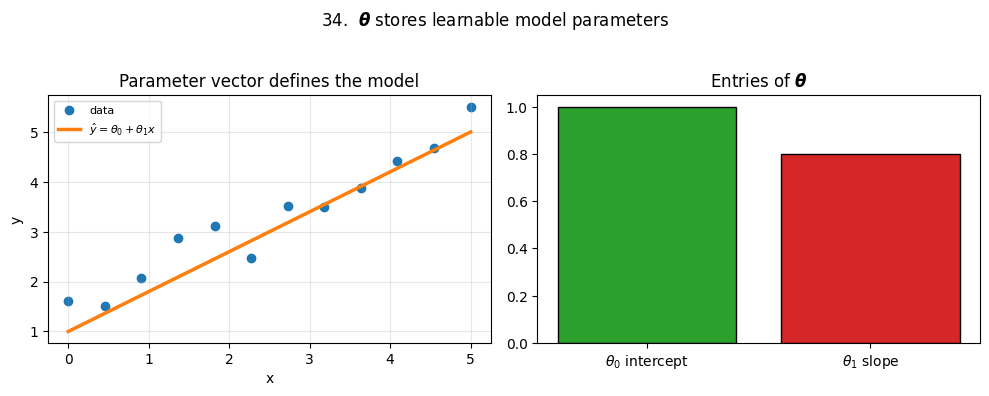

In [34]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(0)
theta = np.array([1.0, 0.8])  # theta_0 intercept, theta_1 slope
x = np.linspace(0, 5, 12)
y = theta[0] + theta[1] * x + np.random.normal(0, 0.35, size=x.shape)
grid = np.linspace(0, 5, 100)
y_hat = theta[0] + theta[1] * grid

print("34) theta = [intercept, slope] =", theta)
print("    model: y_hat = theta_0 + theta_1*x")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].scatter(x, y, color="C0", label="data")
axes[0].plot(grid, y_hat, "C1", lw=2.5, label=r"$\hat y=\theta_0+\theta_1x$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Parameter vector defines the model")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].bar([0, 1], theta, color=["C2", "C3"], edgecolor="k")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels([r"$\theta_0$ intercept", r"$\theta_1$ slope"])
axes[1].axhline(0, color="gray", lw=0.6)
axes[1].set_title(r"Entries of $\boldsymbol{\theta}$")
plt.suptitle(r"34.  $\boldsymbol{\theta}$ stores learnable model parameters", y=1.03)
plt.tight_layout()
plt.show()


**What the visual shows:** The left plot shows a model produced by two parameters: intercept and slope. The right plot makes those learned numbers explicit as entries of $\boldsymbol{\theta}$.


## 35. $\frac{\partial f}{\partial x}$ — partial derivative

**Notation:** $\frac{\partial f}{\partial x}$ is the derivative of $f$ **holding other variables fixed** (e.g. $y,z$ constant).


**Theory:** Partial derivatives let us study multivariable functions one coordinate direction at a time. In ML, every parameter has a partial derivative of the loss; stacking those partials gives the gradient used by gradient descent and backpropagation.

**Math example:** $f(x,y)=x^2 y$. Then $\frac{\partial f}{\partial x}=2xy$, $\frac{\partial f}{\partial y}=x^2$.


**Best example:** Freeze $y$ and show the partial derivative as the tangent slope of the resulting one-variable slice.

**Visualize:** compare analytic partial at a point to a finite-difference check.


35) f(x,y)=x^2 y
    partial df/dx at (1.5,2) = 6.0


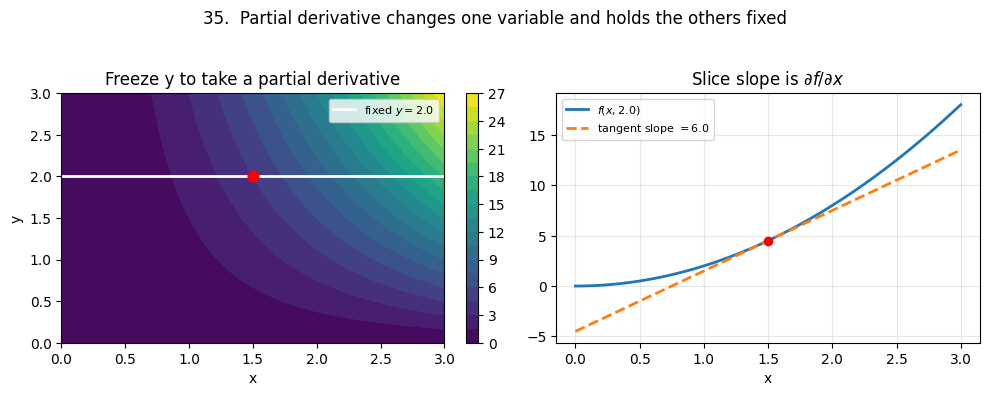

In [35]:
import matplotlib.pyplot as plt
import numpy as np

def f(x, y):
    return (x ** 2) * y

x0, y0 = 1.5, 2.0
dfdx = 2 * x0 * y0
xs = np.linspace(0, 3, 120)
ys = np.linspace(0, 3, 120)
X, Y = np.meshgrid(xs, ys)
Z = f(X, Y)
slice_vals = f(xs, y0)
tangent = f(x0, y0) + dfdx * (xs - x0)

print("35) f(x,y)=x^2 y")
print("    partial df/dx at (1.5,2) =", dfdx)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
cs = axes[0].contourf(X, Y, Z, levels=20, cmap="viridis")
axes[0].axhline(y0, color="white", lw=2, label=rf"fixed $y={y0}$")
axes[0].scatter([x0], [y0], color="red", s=60, zorder=5)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Freeze y to take a partial derivative")
axes[0].legend(fontsize=8)
plt.colorbar(cs, ax=axes[0], fraction=0.046)

axes[1].plot(xs, slice_vals, "C0", lw=2, label=rf"$f(x,{y0})$")
axes[1].plot(xs, tangent, "C1--", lw=2, label=rf"tangent slope $={dfdx:.1f}$")
axes[1].scatter([x0], [f(x0, y0)], color="red", zorder=5)
axes[1].set_xlabel("x")
axes[1].set_title(r"Slice slope is $\partial f/\partial x$")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle(r"35.  Partial derivative changes one variable and holds the others fixed", y=1.03)
plt.tight_layout()
plt.show()


**What the visual shows:** Holding $y$ fixed turns the surface into a single curve in $x$. The tangent on that slice is the partial derivative with respect to $x$.


## 36. $\frac{\mathrm{d} f}{\mathrm{d} x}$ — total derivative

**Notation:** $\frac{\mathrm{d} f}{\mathrm{d} x}$ is used when $f$ **ultimately depends only on $x$** (possibly through intermediate variables). It coincides with $\frac{\mathrm{d}}{\mathrm{d}x} f(x)$ in one variable.


**Theory:** The total derivative accounts for every path by which $x$ changes $f$. In one variable it is the usual slope. In composed functions it leads to the chain rule, the core idea behind backpropagation.

**Math example:** If $f(t)=t^3$, then $\frac{\mathrm{d}f}{\mathrm{d}t}=3t^2$.


**Best example:** Use a chain-rule example $f(t)=\sin(t^2)$ so total derivative means all paths from $t$ to $f$ are counted.

**Visualize:** function and tangent slope = derivative at a point.


36) f(t)=sin(t^2)
    df/dt = cos(t^2)*2t, so df/dt at t0 = 0.7766426826825265


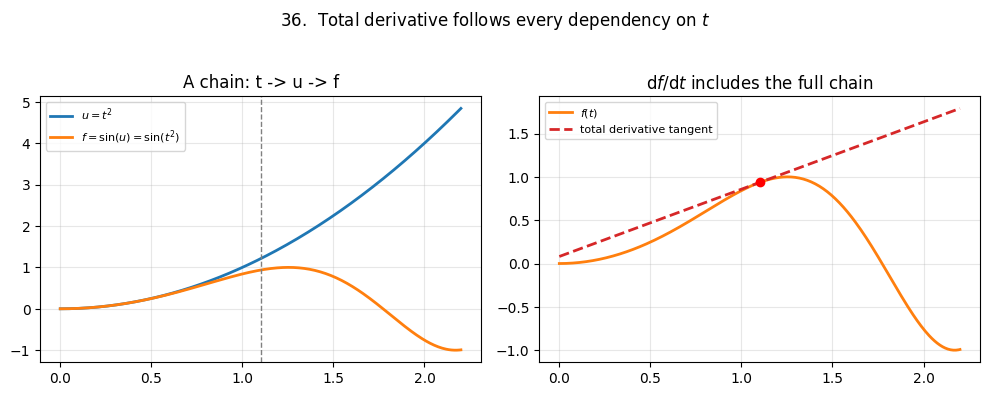

In [36]:
import matplotlib.pyplot as plt
import numpy as np

def f(t):
    return np.sin(t ** 2)

def dfdt(t):
    return np.cos(t ** 2) * 2 * t

t0 = 1.1
ts = np.linspace(0, 2.2, 300)
tangent = f(t0) + dfdt(t0) * (ts - t0)

print("36) f(t)=sin(t^2)")
print("    df/dt = cos(t^2)*2t, so df/dt at t0 =", float(dfdt(t0)))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(ts, ts ** 2, "C0", lw=2, label=r"$u=t^2$")
axes[0].plot(ts, f(ts), "C1", lw=2, label=r"$f=\sin(u)=\sin(t^2)$")
axes[0].axvline(t0, color="gray", ls="--", lw=1)
axes[0].set_title("A chain: t -> u -> f")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(ts, f(ts), "C1", lw=2, label=r"$f(t)$")
axes[1].plot(ts, tangent, "C3--", lw=2, label="total derivative tangent")
axes[1].scatter([t0], [f(t0)], color="red", zorder=5)
axes[1].set_title(r"$\mathrm{d}f/\mathrm{d}t$ includes the full chain")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle(r"36.  Total derivative follows every dependency on $t$", y=1.03)
plt.tight_layout()
plt.show()


**What the visual shows:** The function depends on $t$ through the intermediate value $u=t^2$. The tangent slope includes the full chain $t \to u \to f$, which is the total derivative.


## 37. $\nabla$ — gradient

**Notation:** $\nabla f$ (for scalar $f$) is the vector of **partial derivatives**. For $f:\mathbb{R}^d\to\mathbb{R}$, $\nabla f(\mathbf{x}) = \big(\frac{\partial f}{\partial x_1},\ldots,\frac{\partial f}{\partial x_d}\big)^{\top}$. It points **uphill** on $f$.


**Theory:** The gradient points in the direction of steepest local increase. Moving in the negative gradient direction usually decreases the function fastest for a small step, which is why gradient descent updates parameters by $\boldsymbol{\theta}\leftarrow\boldsymbol{\theta}-\eta\nabla J(\boldsymbol{\theta})$.

**Math example:** $f(x,y)=x^2+y^2$ has $\nabla f=(2x,2y)^{\top}$.


**Best example:** Overlay a gradient-descent path on contours so the negative-gradient direction becomes visible.

**Visualize:** contours and gradient arrows.


37) gradient descent update: theta <- theta - eta * grad f(theta)
    final point after steps: [ 0.99999309 -0.98174474]


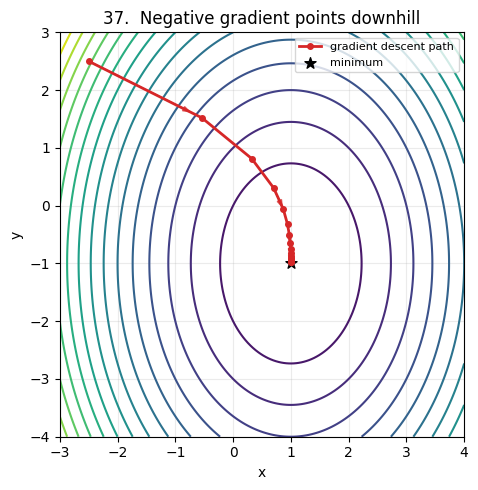

In [37]:
import matplotlib.pyplot as plt
import numpy as np

def f(x, y):
    return (x - 1) ** 2 + 0.5 * (y + 1) ** 2

def grad(x, y):
    return np.array([2 * (x - 1), y + 1])

xg = np.linspace(-3, 4, 160)
yg = np.linspace(-4, 3, 160)
X, Y = np.meshgrid(xg, yg)
Z = f(X, Y)

eta = 0.28
p = np.array([-2.5, 2.5])
path = [p.copy()]
for _ in range(16):
    p = p - eta * grad(p[0], p[1])
    path.append(p.copy())
path = np.array(path)

print("37) gradient descent update: theta <- theta - eta * grad f(theta)")
print("    final point after steps:", path[-1])

fig, ax = plt.subplots(figsize=(6, 5))
ax.contour(X, Y, Z, levels=18, cmap="viridis")
ax.plot(path[:, 0], path[:, 1], "o-", color="C3", lw=2, ms=4, label="gradient descent path")
ax.scatter([1], [-1], color="black", s=70, marker="*", label="minimum")
for i in range(0, len(path) - 1, 3):
    g = grad(path[i, 0], path[i, 1])
    ax.arrow(path[i, 0], path[i, 1], -0.25 * g[0], -0.25 * g[1], color="C3", head_width=0.08, length_includes_head=True, alpha=0.7)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"37.  Negative gradient points downhill")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


**What the visual shows:** Gradient descent moves across contours toward smaller loss values. Each step follows the negative gradient, and the path bends as the local gradient direction changes.


## 38. $\mathcal{L}$ — Lagrangian

**Notation:** For equality constraint $g(\mathbf{x})=0$, the **Lagrangian** is $\mathcal{L}(\mathbf{x},\lambda)=f(\mathbf{x})+\lambda\, g(\mathbf{x})$ (sign convention can vary). Stationary points of $\mathcal{L}$ relate to constrained extrema of $f$.


**Theory:** Lagrange multipliers turn a constrained optimization problem into equations involving both the objective and the constraint. At a constrained optimum, the gradient of the objective is balanced by the gradient of the constraint.

**Math example:** Minimize $x^2$ subject to $x-1=0$: $\mathcal{L}(x,\lambda)=x^2+\lambda(x-1)$.


**Best example:** Use constrained optimization with contour lines and a constraint line; the optimum lies where the constraint touches the best contour.

**Visualize:** $\mathcal{L}$ vs $x$ for a few $\lambda$ values (slice).


38) minimize (x-2)^2+(y-1)^2 subject to x+y=1
    unconstrained minimum: [2. 1.] constrained optimum: [1. 0.]


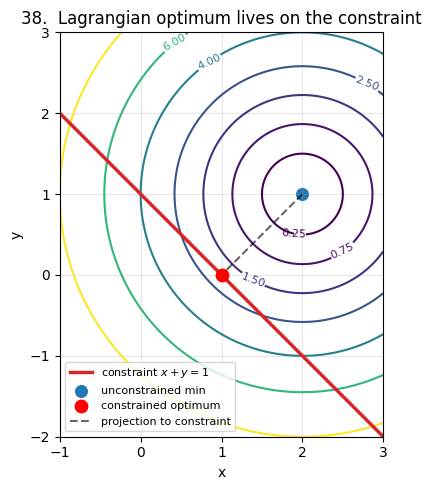

In [38]:
import matplotlib.pyplot as plt
import numpy as np

def f(x, y):
    return (x - 2) ** 2 + (y - 1) ** 2

xg = np.linspace(-1, 3, 200)
yg = np.linspace(-2, 3, 200)
X, Y = np.meshgrid(xg, yg)
Z = f(X, Y)
constraint_x = np.linspace(-1, 3, 200)
constraint_y = 1 - constraint_x
unconstrained = np.array([2.0, 1.0])
opt = np.array([1.0, 0.0])

print("38) minimize (x-2)^2+(y-1)^2 subject to x+y=1")
print("    unconstrained minimum:", unconstrained, "constrained optimum:", opt)

fig, ax = plt.subplots(figsize=(6, 5))
cs = ax.contour(X, Y, Z, levels=[0.25, 0.75, 1.5, 2.5, 4, 6, 9], cmap="viridis")
ax.clabel(cs, inline=True, fontsize=8)
ax.plot(constraint_x, constraint_y, "C3", lw=2.5, label=r"constraint $x+y=1$")
ax.scatter(*unconstrained, color="C0", s=70, label="unconstrained min")
ax.scatter(*opt, color="red", s=80, zorder=5, label="constrained optimum")
ax.plot([unconstrained[0], opt[0]], [unconstrained[1], opt[1]], "k--", alpha=0.6, label="projection to constraint")
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"38.  Lagrangian optimum lives on the constraint")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**What the visual shows:** The unconstrained minimum is not feasible because it is off the constraint line. The constrained optimum is the best point that still lies on the allowed line.


## 39. Negative log-likelihood (often written $-\log \mathcal{L}$ or $\mathrm{NLL}$)

**Notation:** If $\mathcal{L}(\theta)$ is the **likelihood** (or $\log \mathcal{L}$ the log-likelihood), training often **minimizes** the **negative log-likelihood** $-\log \mathcal{L}(\theta)$, equivalent to **maximum likelihood** when $\mathcal{L}>0$. Do **not** confuse with the **Lagrangian** $\mathcal{L}$ in the previous section—**context** (optimization of density vs constrained optimization) tells them apart.


**Theory:** Logs turn products of probabilities into sums, making optimization easier and numerically safer. The negative sign converts a maximization problem into a minimization problem. Do not confuse likelihood $\mathcal{L}$ with the Lagrangian $\mathcal{L}$; context decides.

**Math example:** Bernoulli with $P(Y=1)=p$: for observed $y=1$, $\mathrm{NLL}=-\log p$.


**Best example:** Compare low and high predicted probabilities for the true label; NLL strongly punishes confident wrong predictions.

**Visualize:** $-\log p$ for $p\in(0,1)$.


39) NLL for true-class probabilities 0.9, 0.5, 0.1: [0.10536052 0.69314718 2.30258509]


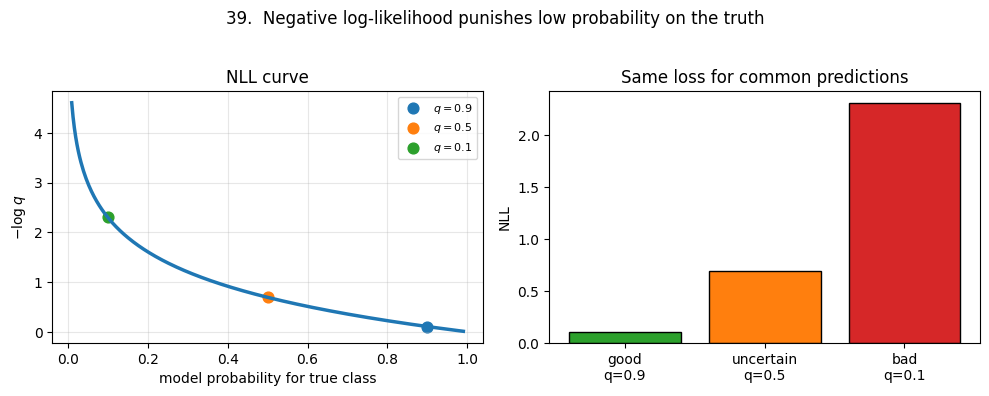

In [39]:
import matplotlib.pyplot as plt
import numpy as np

p = np.linspace(0.01, 0.99, 300)
nll_true = -np.log(p)
examples = np.array([0.9, 0.5, 0.1])
losses = -np.log(examples)

print("39) NLL for true-class probabilities 0.9, 0.5, 0.1:", losses)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(p, nll_true, "C0", lw=2.5)
for q, loss in zip(examples, losses):
    axes[0].scatter([q], [loss], s=60, label=rf"$q={q}$")
axes[0].set_xlabel("model probability for true class")
axes[0].set_ylabel(r"$-\log q$")
axes[0].set_title("NLL curve")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].bar(["good\nq=0.9", "uncertain\nq=0.5", "bad\nq=0.1"], losses, color=["C2", "C1", "C3"], edgecolor="k")
axes[1].set_ylabel("NLL")
axes[1].set_title("Same loss for common predictions")

plt.suptitle(r"39.  Negative log-likelihood punishes low probability on the truth", y=1.03)
plt.tight_layout()
plt.show()


**What the visual shows:** The loss curve becomes steep when the model gives tiny probability to the true class. The bars summarize the same idea: good predictions have low NLL; bad predictions have high NLL.


## 40. $\binom{n}{k}$ — binomial coefficient (“$n$ choose $k$”)

**Notation:** $\binom{n}{k}=\frac{n!}{k!(n-k)!}$ counts **$k$-subsets** of an $n$-set (coefficients in $(a+b)^n$).


**Theory:** Binomial coefficients appear in counting, Pascal's triangle, the binomial theorem, and the binomial distribution. In probability, they count how many outcome sequences produce the same number of successes.

**Math example:** $\binom{5}{2}=10$.


**Best example:** Show both Pascal's triangle and the concrete $\binom{5}{2}=10$ pairs.

**Visualize:** small Pascal-style heatmap for $n\leq 8$.


40) C(5,2) = 10 pairs: [('A', 'B'), ('A', 'C'), ('A', 'D'), ('A', 'E'), ('B', 'C'), ('B', 'D'), ('B', 'E'), ('C', 'D'), ('C', 'E'), ('D', 'E')]


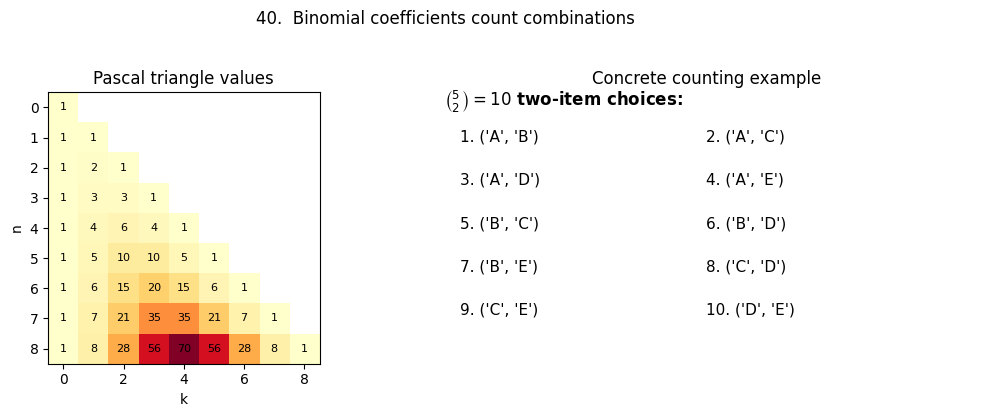

In [40]:
import matplotlib.pyplot as plt
import numpy as np
from math import comb
from itertools import combinations

N = 8
M = np.full((N + 1, N + 1), np.nan)
for n in range(N + 1):
    for k in range(n + 1):
        M[n, k] = comb(n, k)

items = ["A", "B", "C", "D", "E"]
pairs = list(combinations(items, 2))
print("40) C(5,2) =", comb(5, 2), "pairs:", pairs)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
im = axes[0].imshow(M, cmap="YlOrRd")
for n in range(N + 1):
    for k in range(n + 1):
        axes[0].text(k, n, int(M[n, k]), ha="center", va="center", fontsize=8)
axes[0].set_xlabel("k")
axes[0].set_ylabel("n")
axes[0].set_title("Pascal triangle values")

axes[1].axis("off")
axes[1].text(0.02, 0.95, r"$\binom{5}{2}=10$ two-item choices:", fontsize=12, weight="bold", transform=axes[1].transAxes)
for i, pair in enumerate(pairs):
    x = 0.05 + (i % 2) * 0.45
    y = 0.82 - (i // 2) * 0.16
    axes[1].text(x, y, f"{i+1}. {pair}", fontsize=11, transform=axes[1].transAxes)
axes[1].set_title("Concrete counting example")

plt.suptitle(r"40.  Binomial coefficients count combinations", y=1.03)
plt.tight_layout()
plt.show()


**What the visual shows:** Pascal's triangle stores all small binomial coefficients. The pair list makes $\binom{5}{2}=10$ concrete by showing the ten possible two-item choices.


## 41. $\mathbb{V}_{X}[X]$ or $\mathrm{Var}(X)$ — variance

**Notation:** $\mathbb{V}_{X}[X]$ (or $\mathrm{Var}(X)$) is $\mathbb{E}[(X-\mathbb{E}[X])^2]$. Subscript $X$ stresses **which random variable** is being averaged over.


**Theory:** Variance measures average squared spread around the mean. Squaring makes negative and positive deviations both count positively and penalizes large deviations more. Standard deviation is the square root of variance, returning to the original units.

**Math example:** If $X\sim\mathrm{Bernoulli}(p)$, $\mathrm{Var}(X)=p(1-p)$.


**Best example:** Compare two datasets with the same mean but different spread, making variance visually obvious.

**Visualize:** sample spread around the mean.


41) low variance sample var: 0.33859056459561476
    high variance sample var: 3.368796110679252


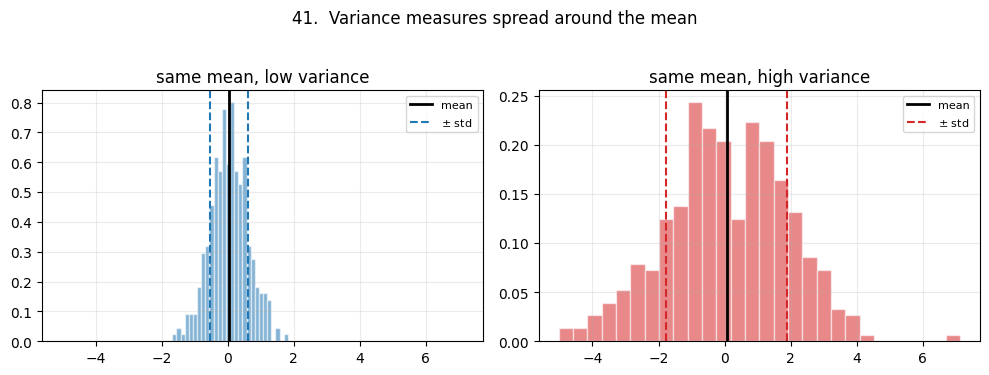

In [41]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(1)
low = np.random.normal(0, 0.6, 350)
high = np.random.normal(0, 1.8, 350)

print("41) low variance sample var:", np.var(low, ddof=1))
print("    high variance sample var:", np.var(high, ddof=1))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharex=True)
for ax, data, title, color in [(axes[0], low, "same mean, low variance", "C0"), (axes[1], high, "same mean, high variance", "C3")]:
    ax.hist(data, bins=28, density=True, alpha=0.55, color=color, edgecolor="white")
    ax.axvline(np.mean(data), color="black", lw=2, label="mean")
    ax.axvline(np.mean(data) - np.std(data, ddof=1), color=color, ls="--", lw=1.5, label=r"$\pm$ std")
    ax.axvline(np.mean(data) + np.std(data, ddof=1), color=color, ls="--", lw=1.5)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

plt.suptitle(r"41.  Variance measures spread around the mean", y=1.03)
plt.tight_layout()
plt.show()


**What the visual shows:** Both groups are centered at the same mean, but the high-variance group spreads much farther away. Variance is about spread, not about the center alone.


## 42. $\mathbb{E}_{X}[X]$ — expectation

**Notation:** $\mathbb{E}_{X}[g(X)]$ averages $g(X)$ over the distribution of $X$. For discrete $X$, $\mathbb{E}[X]=\sum_x x\, P(X=x)$.


**Theory:** Expectation is the probability-weighted long-run average, not necessarily the most likely value. In ML, losses are often written as expectations because training tries to minimize average future error under a data distribution.

**Math example:** Fair die: $\mathbb{E}[X]=(1+\cdots+6)/6=3.5$.


**Best example:** Show expectation as both a probability-weighted center of mass and a running average.

**Visualize:** running sample mean approaching $\mathbb{E}[X]$ for a die.


42) E[X] for loaded die = 4.3
    running mean after 1200 samples = 4.234166666666667


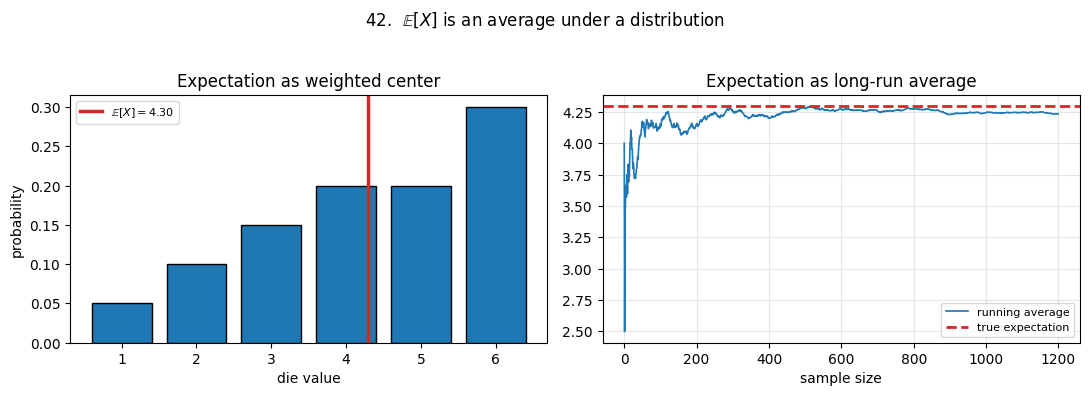

In [42]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(2)
values = np.arange(1, 7)
probs = np.array([0.05, 0.10, 0.15, 0.20, 0.20, 0.30])
expected = np.sum(values * probs)
rolls = np.random.choice(values, size=1200, p=probs)
running = np.cumsum(rolls) / np.arange(1, len(rolls) + 1)

print("42) E[X] for loaded die =", expected)
print("    running mean after 1200 samples =", running[-1])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].bar(values, probs, color="C0", edgecolor="k")
axes[0].axvline(expected, color="C3", lw=2.5, label=rf"$\mathbb{{E}}[X]={expected:.2f}$")
axes[0].set_xlabel("die value")
axes[0].set_ylabel("probability")
axes[0].set_title("Expectation as weighted center")
axes[0].legend(fontsize=8)

axes[1].plot(running, color="C0", lw=1.2, label="running average")
axes[1].axhline(expected, color="C3", ls="--", lw=2, label="true expectation")
axes[1].set_xlabel("sample size")
axes[1].set_title("Expectation as long-run average")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle(r"42.  $\mathbb{E}[X]$ is an average under a distribution", y=1.03)
plt.tight_layout()
plt.show()


**What the visual shows:** The bar chart shows expectation as a weighted center. The running mean plot shows the same value emerging from many repeated samples.


## 43. $\mathrm{Cov}_{X,Y}(X,Y)$ — covariance

**Notation:** $\mathrm{Cov}(X,Y)=\mathbb{E}[(X-\mathbb{E}X)(Y-\mathbb{E}Y)]$. Positive covariance means **tendency** to increase together.


**Theory:** Covariance measures whether two variables tend to move together. Positive covariance means they usually increase together; negative covariance means one tends to increase when the other decreases. Its scale depends on units, so correlation normalizes covariance into $[-1,1]$.

**Math example:** If $Y=X+\varepsilon$ with independent mean-zero $\varepsilon$, $\mathrm{Cov}(X,Y)=\mathrm{Var}(X)$.


**Best example:** Compare positive, negative, and near-zero covariance scatter plots side by side.

**Visualize:** scatter + covariance matrix heatmap.


43) covariance signs: [('positive covariance', 1.0158557010693756), ('negative covariance', -0.9890032236215124), ('near-zero covariance', -0.13973876579074052)]


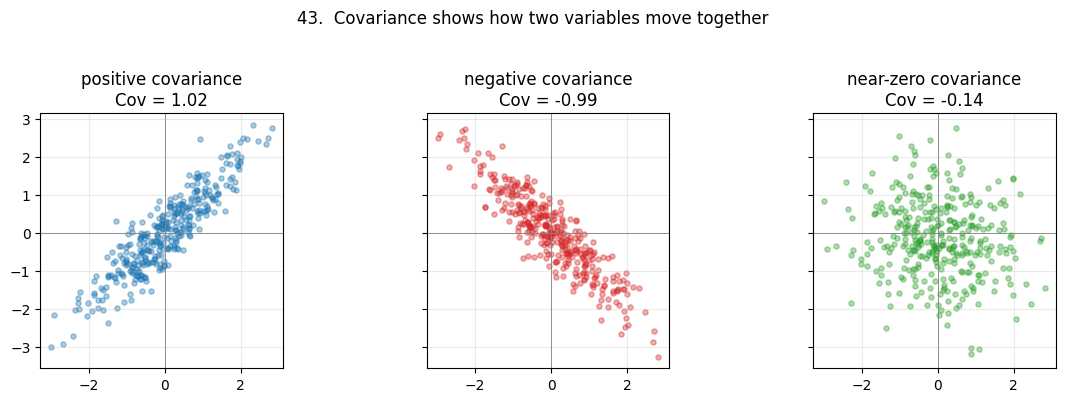

In [43]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(3)
n = 350
x = np.random.randn(n)
datasets = [
    ("positive covariance", x, 0.9 * x + 0.45 * np.random.randn(n), "C0"),
    ("negative covariance", x, -0.9 * x + 0.45 * np.random.randn(n), "C3"),
    ("near-zero covariance", x, np.random.randn(n), "C2"),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharex=True, sharey=True)
for ax, (title, xs, ys, color) in zip(axes, datasets):
    cov = np.cov(xs, ys)[0, 1]
    ax.scatter(xs, ys, alpha=0.38, s=14, color=color)
    ax.axhline(0, color="gray", lw=0.6)
    ax.axvline(0, color="gray", lw=0.6)
    ax.set_title(f"{title}\nCov = {cov:.2f}")
    ax.grid(True, alpha=0.25)
    ax.set_aspect("equal", adjustable="box")

print("43) covariance signs:", [(title, float(np.cov(xs, ys)[0, 1])) for title, xs, ys, _ in datasets])
plt.suptitle(r"43.  Covariance shows how two variables move together", y=1.04)
plt.tight_layout()
plt.show()


**What the visual shows:** Upward slope means positive covariance, downward slope means negative covariance, and a round cloud means near-zero covariance.


## 44. $X \perp\!\!\!\perp Y \mid Z$ — conditional independence

**Notation:** $X$ is **conditionally independent** of $Y$ given $Z$ if $P(X,Y\mid Z)=P(X\mid Z)\,P(Y\mid Z)$ (equivalently $X\mid Z$ and $Y\mid Z$ are independent). The symbol $\perp\!\!\!\perp$ is read “independent”.


**Theory:** Conditional independence says that once $Z$ is known, observing $Y$ gives no extra information about $X$. This is central in graphical models, causal reasoning, and probabilistic factorization.

**Math example:** In a Bayesian network, missing edges often encode such statements.


**Best example:** Use a common-cause example where $X$ and $Y$ look related overall but become independent after conditioning on $Z$.

**Visualize:** conceptual sketch (no plot): **given $Z$**, knowing $Y$ does not change beliefs about $X$.


44) overall corr(X,Y) = 0.7725953887885376
    corr(X,Y | Z=0) = -0.002464905572656331 corr(X,Y | Z=1) = -0.02985245562572565


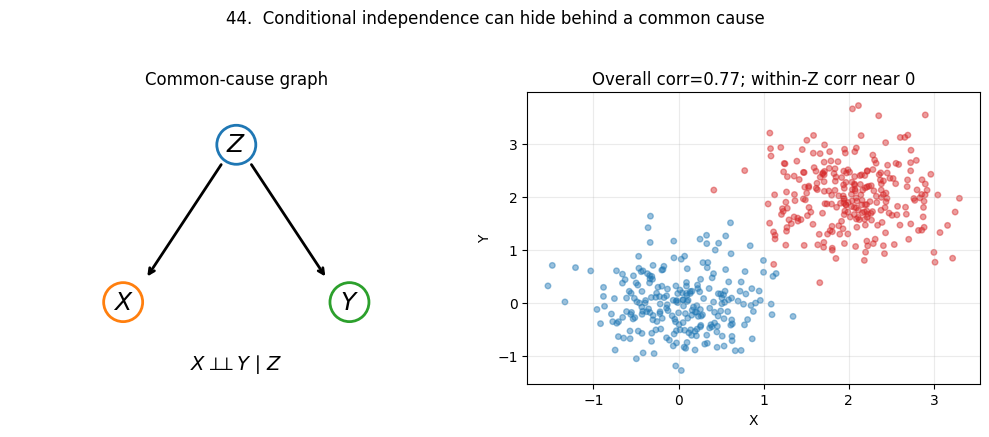

In [44]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(4)
n = 500
Z = np.random.binomial(1, 0.5, size=n)
X = 2 * Z + np.random.randn(n) * 0.55
Y = 2 * Z + np.random.randn(n) * 0.55

overall_corr = np.corrcoef(X, Y)[0, 1]
corr_z0 = np.corrcoef(X[Z == 0], Y[Z == 0])[0, 1]
corr_z1 = np.corrcoef(X[Z == 1], Y[Z == 1])[0, 1]
print("44) overall corr(X,Y) =", overall_corr)
print("    corr(X,Y | Z=0) =", corr_z0, "corr(X,Y | Z=1) =", corr_z1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
axes[0].axis("off")
axes[0].text(0.5, 0.82, r"$Z$", ha="center", va="center", fontsize=18, bbox=dict(boxstyle="circle", fc="white", ec="C0", lw=2), transform=axes[0].transAxes)
axes[0].text(0.25, 0.28, r"$X$", ha="center", va="center", fontsize=18, bbox=dict(boxstyle="circle", fc="white", ec="C1", lw=2), transform=axes[0].transAxes)
axes[0].text(0.75, 0.28, r"$Y$", ha="center", va="center", fontsize=18, bbox=dict(boxstyle="circle", fc="white", ec="C2", lw=2), transform=axes[0].transAxes)
axes[0].annotate("", xy=(0.30, 0.36), xytext=(0.47, 0.76), arrowprops=dict(arrowstyle="->", lw=2), xycoords="axes fraction")
axes[0].annotate("", xy=(0.70, 0.36), xytext=(0.53, 0.76), arrowprops=dict(arrowstyle="->", lw=2), xycoords="axes fraction")
axes[0].text(0.5, 0.05, r"$X \perp\!\!\!\perp Y \mid Z$", ha="center", fontsize=14, transform=axes[0].transAxes)
axes[0].set_title("Common-cause graph")

colors = np.where(Z == 0, "C0", "C3")
axes[1].scatter(X, Y, c=colors, alpha=0.45, s=16)
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")
axes[1].set_title(f"Overall corr={overall_corr:.2f}; within-Z corr near 0")
axes[1].grid(True, alpha=0.25)

plt.suptitle(r"44.  Conditional independence can hide behind a common cause", y=1.03)
plt.tight_layout()
plt.show()


**What the visual shows:** Overall, colors mixed together can make $X$ and $Y$ appear related. Within each value of $Z$, the relationship largely disappears, illustrating conditional independence.


## 45. $X \sim p$ — “$X$ is distributed according to $p$”

**Notation:** $X\sim p$ means random variable $X$ follows **distribution** $p$ (density $p(x)$ if continuous, pmf if discrete).


**Theory:** The symbol $\sim$ links a random variable to the rule that generates its probabilities. Once the distribution is known, we can compute probabilities, expectations, variances, likelihoods, and samples.

**Math example:** $X\sim \mathcal{N}(0,1)$: standard Gaussian.


**Best example:** Show samples from a named distribution against the theoretical density that generated them.

**Visualize:** histogram of samples vs true density curve.


45) X ~ N(1, 1.5^2)
    sample mean: 0.9872434112173505 sample std: 1.4942724253936586


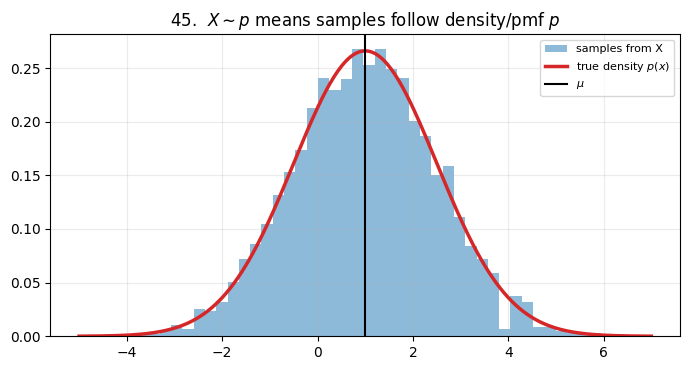

In [45]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(5)
mu, sigma = 1.0, 1.5
samples = np.random.normal(mu, sigma, 2500)
grid = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 300)
pdf = np.exp(-0.5 * ((grid - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))

print("45) X ~ N(1, 1.5^2)")
print("    sample mean:", samples.mean(), "sample std:", samples.std(ddof=1))

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.hist(samples, bins=45, density=True, alpha=0.5, color="C0", label="samples from X")
ax.plot(grid, pdf, "C3", lw=2.5, label=r"true density $p(x)$")
ax.axvline(mu, color="black", lw=1.5, label=r"$\mu$")
ax.set_title(r"45.  $X\sim p$ means samples follow density/pmf $p$")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


**What the visual shows:** The histogram is empirical evidence from samples. The smooth curve is the probability density $p$ in the statement $X\sim p$.


## 46. $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ — multivariate Gaussian

**Notation:** **Multivariate normal** with mean vector $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$. Density involves $\exp\big(-\tfrac12(\mathbf{x}-\boldsymbol{\mu})^{\top}\boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu})\big)$.


**Theory:** The mean controls the center, while the covariance controls spread, orientation, and correlation. Diagonal covariance gives axis-aligned ellipses; off-diagonal covariance tilts the ellipses because variables move together.

**Math example:** Standard 2D case $\mathcal{N}(\mathbf{0}, I)$: circular contours.


**Best example:** Compare independent and correlated 2D Gaussians using covariance ellipses.

**Visualize:** samples + covariance ellipse.


46) covariance matrix controls shape and tilt of Gaussian samples.


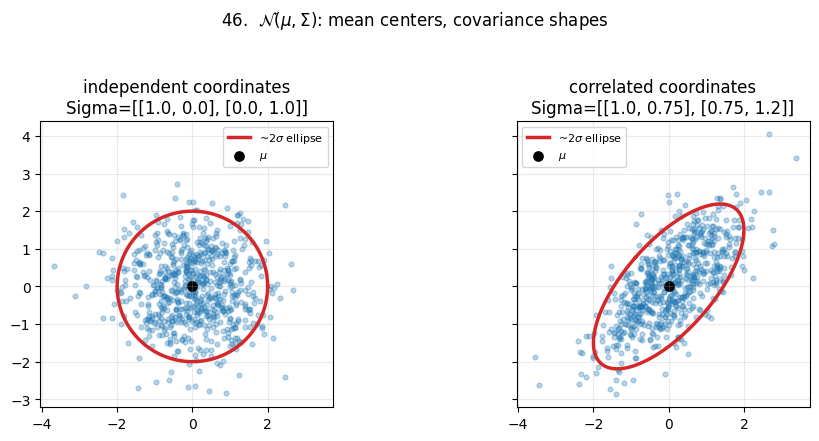

In [46]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(6)
mu = np.array([0.0, 0.0])
covs = [
    ("independent coordinates", np.array([[1.0, 0.0], [0.0, 1.0]])),
    ("correlated coordinates", np.array([[1.0, 0.75], [0.75, 1.2]])),
]

def ellipse_points(Sigma, scale=2.0):
    vals, vecs = np.linalg.eigh(Sigma)
    t = np.linspace(0, 2 * np.pi, 200)
    circle = np.stack([np.cos(t), np.sin(t)])
    return vecs @ np.diag(scale * np.sqrt(vals)) @ circle

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharex=True, sharey=True)
for ax, (title, Sigma) in zip(axes, covs):
    L = np.linalg.cholesky(Sigma)
    X = np.random.randn(700, 2) @ L.T + mu
    ell = ellipse_points(Sigma)
    ax.scatter(X[:, 0], X[:, 1], alpha=0.3, s=12)
    ax.plot(ell[0], ell[1], "C3", lw=2.5, label=r"~2$\sigma$ ellipse")
    ax.scatter([0], [0], color="black", s=45, label=r"$\mu$")
    ax.set_title(title + f"\nSigma={Sigma.tolist()}")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)

print("46) covariance matrix controls shape and tilt of Gaussian samples.")
plt.suptitle(r"46.  $\mathcal{N}(\mu,\Sigma)$: mean centers, covariance shapes", y=1.04)
plt.tight_layout()
plt.show()


**What the visual shows:** The circular/axis-aligned cloud has no correlation. The tilted ellipse shows covariance between coordinates, so large $x$ tends to come with large $y$.


## 47. $\mathrm{Ber}(\mu)$ — Bernoulli distribution

**Notation:** $X\in\{0,1\}$ with $P(X=1)=\mu$, $P(X=0)=1-\mu$. Models a **single** binary trial.


**Theory:** Bernoulli models one binary trial: success/failure, yes/no, click/no-click. It is the building block for binary classification likelihoods and for the binomial distribution.

**Math example:** $\mu=0.3$: bar heights $0.7$ at $0$ and $0.3$ at $1$.


**Best example:** Show both the Bernoulli pmf and a simulated sequence of binary trials.

**Visualize:** pmf bars.


47) Bernoulli mean = 0.35 variance = 0.22749999999999998
    sample mean after 80 trials = 0.325


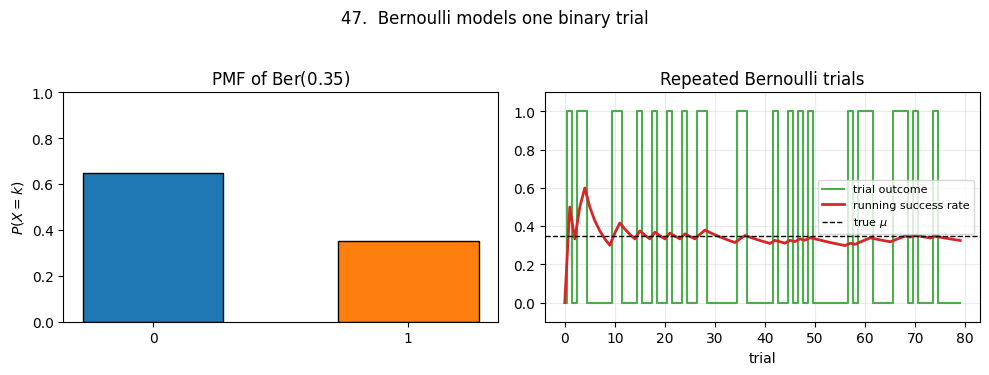

In [47]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(7)
mu = 0.35
trials = np.random.binomial(1, mu, size=80)
running = np.cumsum(trials) / np.arange(1, len(trials) + 1)

print("47) Bernoulli mean =", mu, "variance =", mu * (1 - mu))
print("    sample mean after 80 trials =", running[-1])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].bar([0, 1], [1 - mu, mu], color=["C0", "C1"], width=0.55, edgecolor="k")
axes[0].set_xticks([0, 1])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel(r"$P(X=k)$")
axes[0].set_title(rf"PMF of $\mathrm{{Ber}}({mu})$")

axes[1].step(np.arange(len(trials)), trials, where="mid", color="C2", alpha=0.85, label="trial outcome")
axes[1].plot(running, "C3", lw=2, label="running success rate")
axes[1].axhline(mu, color="black", ls="--", lw=1, label=r"true $\mu$")
axes[1].set_ylim(-0.1, 1.1)
axes[1].set_xlabel("trial")
axes[1].set_title("Repeated Bernoulli trials")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.25)

plt.suptitle(r"47.  Bernoulli models one binary trial", y=1.03)
plt.tight_layout()
plt.show()


**What the visual shows:** The pmf has only two bars because Bernoulli has only two outcomes. The simulated sequence shows the same distribution as repeated 0/1 trials.


## 48. $\mathrm{Bin}(N,\mu)$ — Binomial distribution

**Notation:** Sum of $N$ i.i.d. $\mathrm{Ber}(\mu)$ trials; $P(X=k)=\binom{N}{k}\mu^k(1-\mu)^{N-k}$ for $k=0,\ldots,N$.


**Theory:** Binomial counts how many successes occur in a fixed number of identical independent trials. Its mean is $N\mu$ and its variance is $N\mu(1-\mu)$.

**Math example:** $N=10$, $\mu=0.4$: unimodal pmf around $N\mu=4$.


**Best example:** Show the binomial pmf, mark its mean, and connect it to the number of successes in repeated trials.

**Visualize:** pmf bars.


48) Bin(N,mu) with N=12, mu=0.45
    mean = 5.4 variance = 2.9700000000000006 pmf sum = 1.0000000000000004


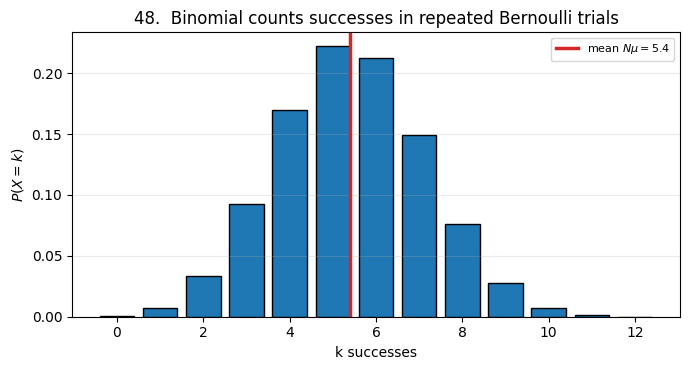

In [48]:
import matplotlib.pyplot as plt
import numpy as np
from math import comb

N, mu = 12, 0.45
ks = np.arange(N + 1)
pmf = np.array([comb(N, k) * mu ** k * (1 - mu) ** (N - k) for k in ks])
mean = N * mu
var = N * mu * (1 - mu)

print("48) Bin(N,mu) with N=12, mu=0.45")
print("    mean =", mean, "variance =", var, "pmf sum =", pmf.sum())

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.bar(ks, pmf, color="C0", edgecolor="k")
ax.axvline(mean, color="C3", lw=2.5, label=rf"mean $N\mu={mean:.1f}$")
ax.set_xlabel("k successes")
ax.set_ylabel(r"$P(X=k)$")
ax.set_title(r"48.  Binomial counts successes in repeated Bernoulli trials")
ax.legend(fontsize=8)
ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


**What the visual shows:** Each bar is the probability of exactly $k$ successes. The dashed line marks $N\mu$, the expected number of successes.


## 49. $\mathrm{Beta}(\alpha,\beta)$ — Beta distribution

**Notation:** Continuous distribution on $(0,1)$ with density $\propto x^{\alpha-1}(1-x)^{\beta-1}$. Common **prior** for a probability parameter.


**Theory:** Beta distributions are flexible distributions over probabilities. In Bayesian modeling, Beta is conjugate to Bernoulli/binomial likelihoods, so it is commonly used as a prior for an unknown probability.

**Math example:** $\mathrm{Beta}(2,5)$ peaks toward $0$; $\mathrm{Beta}(5,2)$ toward $1$.


**Best example:** Show Beta prior-to-posterior updating after observing successes and failures.

**Visualize:** pdf curves for several $(\alpha,\beta)$.


49) prior Beta(2,2), data: 6 successes and 2 failures
    posterior Beta (8, 4) observed success rate = 0.75


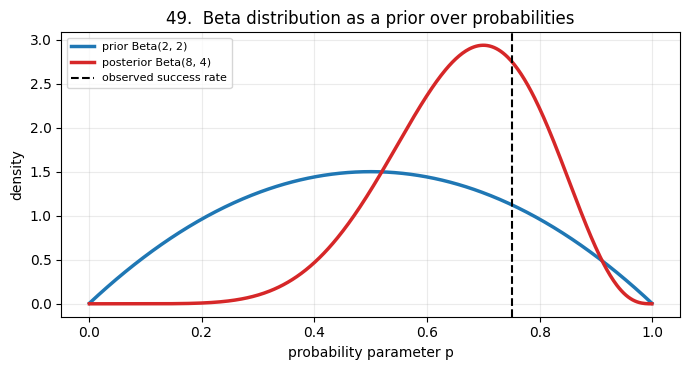

In [49]:
import matplotlib.pyplot as plt
import numpy as np
from math import gamma

def beta_pdf(x, a, b):
    B = gamma(a) * gamma(b) / gamma(a + b)
    return x ** (a - 1) * (1 - x) ** (b - 1) / B

x = np.linspace(0.001, 0.999, 500)
prior = (2, 2)
successes, failures = 6, 2
posterior = (prior[0] + successes, prior[1] + failures)
rate = successes / (successes + failures)

print("49) prior Beta(2,2), data: 6 successes and 2 failures")
print("    posterior Beta", posterior, "observed success rate =", rate)

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(x, beta_pdf(x, *prior), "C0", lw=2.5, label=rf"prior Beta{prior}")
ax.plot(x, beta_pdf(x, *posterior), "C3", lw=2.5, label=rf"posterior Beta{posterior}")
ax.axvline(rate, color="black", ls="--", lw=1.5, label="observed success rate")
ax.set_xlabel("probability parameter p")
ax.set_ylabel("density")
ax.set_title(r"49.  Beta distribution as a prior over probabilities")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


**What the visual shows:** The posterior curve moves toward the observed success rate after data arrives. This is why Beta distributions are useful priors for unknown probabilities.


## 50. $\arg\min$ and $\arg\max$

**Notation:** $\arg\min_x f(x)$ returns the input value $x$ where $f(x)$ is smallest. $\arg\max_x f(x)$ returns the input where $f(x)$ is largest.

**Theory:** The ordinary minimum is an output value; the argmin is the location that achieves it. ML training is usually written as $\boldsymbol{\theta}^*=\arg\min_{\boldsymbol{\theta}}J(\boldsymbol{\theta})$ because we want the parameter vector, not only the final loss value.

**Math example:** If $f(x)=(x-2)^2+1$, then $\min_x f(x)=1$ but $\arg\min_x f(x)=2$.


**Best example:** Mark both the input location returned by $\arg\min$ and the minimum output value returned by $\min$.

**Visualize:** loss curve with the minimizing input marked.


50) argmin_x f(x) approx = 1.4268537074148298
    min_x f(x) approx = 0.73359181673431


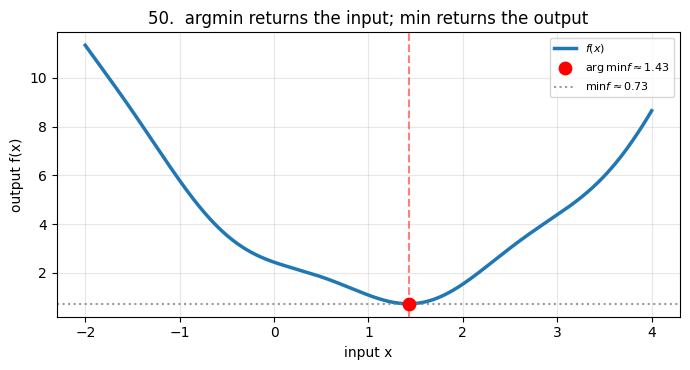

In [50]:
import matplotlib.pyplot as plt
import numpy as np

xs = np.linspace(-2, 4, 500)
f = (xs - 1.2) ** 2 + 0.35 * np.sin(3 * xs) + 1
i_min = np.argmin(f)
x_star = xs[i_min]
y_star = f[i_min]

print("50) argmin_x f(x) approx =", x_star)
print("    min_x f(x) approx =", y_star)

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(xs, f, "C0", lw=2.5, label=r"$f(x)$")
ax.scatter([x_star], [y_star], color="red", s=80, zorder=5, label=rf"$\arg\min f \approx {x_star:.2f}$")
ax.axvline(x_star, color="red", ls="--", alpha=0.5)
ax.axhline(y_star, color="gray", ls=":", alpha=0.8, label=rf"$\min f \approx {y_star:.2f}$")
ax.set_xlabel("input x")
ax.set_ylabel("output f(x)")
ax.set_title(r"50.  argmin returns the input; min returns the output")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**What the visual shows:** The red point's x-coordinate is the argmin, while its y-coordinate is the minimum value. The plot separates the input returned by argmin from the output returned by min.


## 51. Indicator function $\mathbf{1}\{\text{condition}\}$

**Notation:** $\mathbf{1}\{A\}$ equals $1$ if event or condition $A$ is true, and $0$ otherwise.

**Theory:** Indicator functions turn logical statements into numbers, so they can be summed, averaged, or used inside losses. Classification accuracy, for example, can be written as an average of indicators for correct predictions.

**Math example:** $\mathbf{1}\{x>0\}=0$ for $x\leq0$ and $1$ for $x>0$.


**Best example:** Use a threshold classifier so the indicator becomes a visible 0/1 decision rule.

**Visualize:** step function that jumps from $0$ to $1$.


51) indicator 1{score > 0}: [(np.float64(-2.0), np.int64(0)), (np.float64(-1.0), np.int64(0)), (np.float64(-0.4), np.int64(0)), (np.float64(0.2), np.int64(1)), (np.float64(0.9), np.int64(1)), (np.float64(1.7), np.int64(1))]


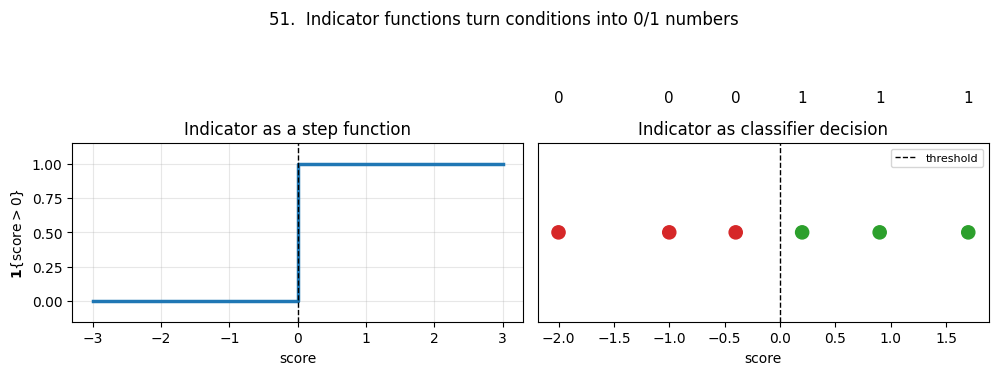

In [51]:
import matplotlib.pyplot as plt
import numpy as np

scores = np.array([-2.0, -1.0, -0.4, 0.2, 0.9, 1.7])
threshold = 0.0
indicators = (scores > threshold).astype(int)
xs = np.linspace(-3, 3, 300)

print("51) indicator 1{score > 0}:", list(zip(scores, indicators)))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].step(xs, (xs > threshold).astype(int), where="post", color="C0", lw=2.5)
axes[0].axvline(threshold, color="black", ls="--", lw=1)
axes[0].set_ylim(-0.15, 1.15)
axes[0].set_xlabel("score")
axes[0].set_ylabel(r"$\mathbf{1}\{\mathrm{score}>0\}$")
axes[0].set_title("Indicator as a step function")
axes[0].grid(True, alpha=0.3)

colors = np.where(indicators == 1, "C2", "C3")
axes[1].scatter(scores, np.zeros_like(scores), c=colors, s=90)
for s, ind in zip(scores, indicators):
    axes[1].text(s, 0.08, str(ind), ha="center", fontsize=11)
axes[1].axvline(threshold, color="black", ls="--", lw=1, label="threshold")
axes[1].set_yticks([])
axes[1].set_xlabel("score")
axes[1].set_title("Indicator as classifier decision")
axes[1].legend(fontsize=8)

plt.suptitle(r"51.  Indicator functions turn conditions into 0/1 numbers", y=1.03)
plt.tight_layout()
plt.show()


**What the visual shows:** Scores below the threshold produce indicator value 0, and scores above it produce 1. The classifier view shows this same rule as decisions on data points.


## 52. Softmax $\operatorname{softmax}(\mathbf{z})$

**Notation:** $\operatorname{softmax}(\mathbf{z})_i=\frac{e^{z_i}}{\sum_j e^{z_j}}$ converts logits into probabilities that sum to $1$.

**Theory:** Softmax preserves ordering: larger logits become larger probabilities. It is used for multiclass classifiers because the output is a categorical distribution over classes. In practice, logits are shifted before exponentiating for numerical stability.

**Math example:** If $\mathbf{z}=(2,1,0)$, the first class receives the largest probability.


**Best example:** Show how softmax temperature changes confidence while preserving the class ranking.

**Visualize:** logits next to their softmax probabilities.


52) logits: [2. 1. 0.]
    softmax temperature 0.5: [0.86681333 0.11731043 0.01587624]
    softmax temperature 1.0: [0.66524096 0.24472847 0.09003057]
    softmax temperature 2.0: [0.50648039 0.30719589 0.18632372]


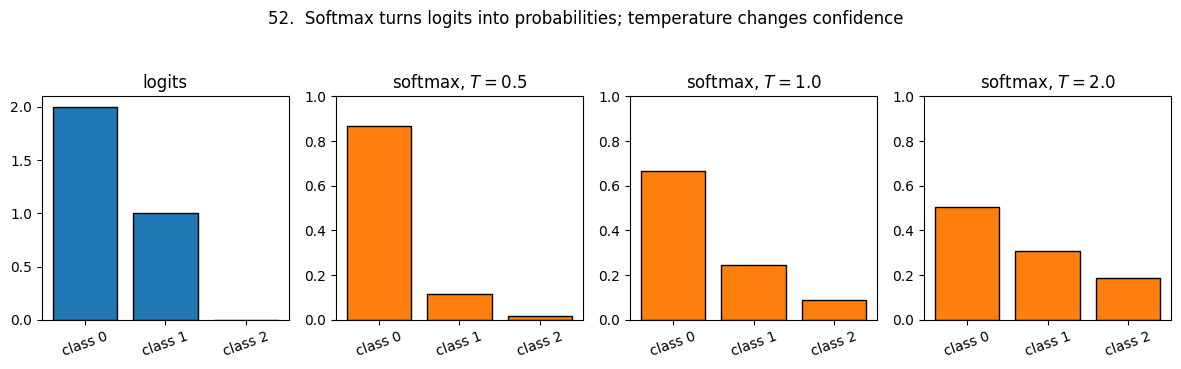

In [52]:
import matplotlib.pyplot as plt
import numpy as np

z = np.array([2.0, 1.0, 0.0])
temps = [0.5, 1.0, 2.0]

def softmax(logits, T=1.0):
    shifted = logits / T - np.max(logits / T)
    e = np.exp(shifted)
    return e / e.sum()

print("52) logits:", z)
for T in temps:
    print(f"    softmax temperature {T}:", softmax(z, T))

fig, axes = plt.subplots(1, 4, figsize=(12, 3.5), sharey=False)
labels = ["class 0", "class 1", "class 2"]
axes[0].bar(labels, z, color="C0", edgecolor="k")
axes[0].set_title("logits")
axes[0].tick_params(axis="x", rotation=20)
for ax, T in zip(axes[1:], temps):
    p = softmax(z, T)
    ax.bar(labels, p, color="C1", edgecolor="k")
    ax.set_ylim(0, 1)
    ax.set_title(rf"softmax, $T={T}$")
    ax.tick_params(axis="x", rotation=20)

plt.suptitle(r"52.  Softmax turns logits into probabilities; temperature changes confidence", y=1.04)
plt.tight_layout()
plt.show()


**What the visual shows:** Lower temperature makes the largest logit dominate. Higher temperature spreads probability more evenly, but the class order remains the same.


## 53. Sigmoid $\sigma(x)$

**Notation:** $\sigma(x)=\frac{1}{1+e^{-x}}$ maps a real number to the interval $(0,1)$.

**Theory:** Sigmoid is often used for binary probabilities. Large positive inputs map near $1$, large negative inputs map near $0$, and $x=0$ maps to $0.5$. Its derivative is $\sigma(x)(1-\sigma(x))$.

**Math example:** $\sigma(0)=0.5$.


**Best example:** Plot the sigmoid and its derivative to show probability squashing and saturation.

**Visualize:** S-shaped curve.


53) sigmoid(0) = 0.5 sigmoid derivative at 0 = 0.25


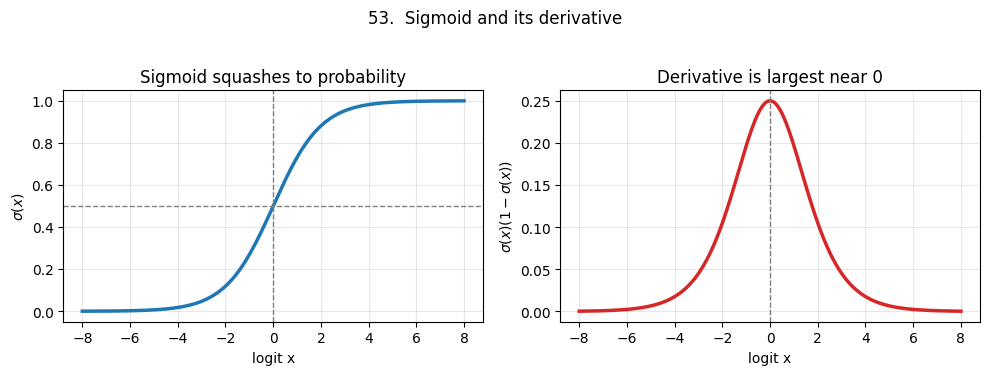

In [53]:
import matplotlib.pyplot as plt
import numpy as np

xs = np.linspace(-8, 8, 400)
sig = 1 / (1 + np.exp(-xs))
deriv = sig * (1 - sig)

print("53) sigmoid(0) =", 0.5, "sigmoid derivative at 0 =", 0.25)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(xs, sig, "C0", lw=2.5)
axes[0].axhline(0.5, color="gray", ls="--", lw=1)
axes[0].axvline(0, color="gray", ls="--", lw=1)
axes[0].set_xlabel("logit x")
axes[0].set_ylabel(r"$\sigma(x)$")
axes[0].set_title("Sigmoid squashes to probability")
axes[0].grid(True, alpha=0.3)

axes[1].plot(xs, deriv, "C3", lw=2.5)
axes[1].axvline(0, color="gray", ls="--", lw=1)
axes[1].set_xlabel("logit x")
axes[1].set_ylabel(r"$\sigma(x)(1-\sigma(x))$")
axes[1].set_title("Derivative is largest near 0")
axes[1].grid(True, alpha=0.3)

plt.suptitle(r"53.  Sigmoid and its derivative", y=1.03)
plt.tight_layout()
plt.show()


**What the visual shows:** The sigmoid converts logits into probabilities. Its derivative is largest near zero and small at the saturated ends, where learning can slow down.


## 54. Cross-entropy $H(p,q)$

**Notation:** For discrete distributions, $H(p,q)=-\sum_i p_i\log q_i$. For one-hot labels, this becomes $-\log q_{\text{true}}$.

**Theory:** Cross-entropy measures how expensive it is to encode data from true distribution $p$ using predicted distribution $q$. In classification, minimizing cross-entropy pushes probability mass onto the correct class.

**Math example:** If the true class is $1$ and the model assigns it probability $0.8$, the loss is $-\log(0.8)$.


**Best example:** Show cross-entropy for good, medium, and bad true-class probabilities.

**Visualize:** loss versus predicted probability for the true class.


54) cross-entropy for true-class probabilities: [(np.float64(0.9), np.float64(0.10536051565782628)), (np.float64(0.5), np.float64(0.6931471805599453)), (np.float64(0.1), np.float64(2.3025850929940455))]


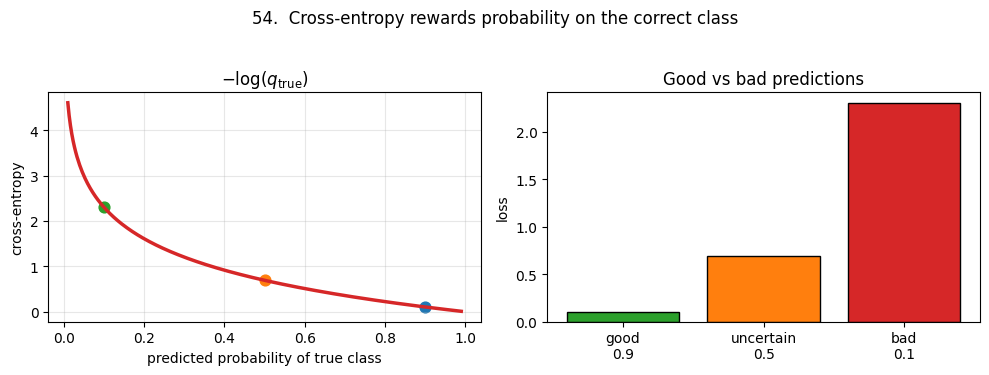

In [54]:
import matplotlib.pyplot as plt
import numpy as np

q = np.linspace(0.01, 0.99, 300)
loss = -np.log(q)
examples = np.array([0.9, 0.5, 0.1])
example_loss = -np.log(examples)

print("54) cross-entropy for true-class probabilities:", list(zip(examples, example_loss)))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(q, loss, "C3", lw=2.5)
for val, los in zip(examples, example_loss):
    axes[0].scatter([val], [los], s=60)
axes[0].set_xlabel("predicted probability of true class")
axes[0].set_ylabel("cross-entropy")
axes[0].set_title(r"$-\log(q_{\mathrm{true}})$")
axes[0].grid(True, alpha=0.3)

axes[1].bar(["good\n0.9", "uncertain\n0.5", "bad\n0.1"], example_loss, color=["C2", "C1", "C3"], edgecolor="k")
axes[1].set_ylabel("loss")
axes[1].set_title("Good vs bad predictions")

plt.suptitle(r"54.  Cross-entropy rewards probability on the correct class", y=1.03)
plt.tight_layout()
plt.show()


**What the visual shows:** Cross-entropy is tiny when the true class gets high probability and grows rapidly when that probability is low.


## 55. KL divergence $D_{\mathrm{KL}}(p\|q)$

**Notation:** $D_{\mathrm{KL}}(p\|q)=\sum_i p_i\log\frac{p_i}{q_i}$ measures how different distribution $q$ is from reference distribution $p$.

**Theory:** KL divergence is nonnegative and equals zero only when $p=q$ on the support of $p$. It is not symmetric, so $D_{\mathrm{KL}}(p\|q)$ and $D_{\mathrm{KL}}(q\|p)$ can differ.

**Math example:** For categorical $p=(0.7,0.2,0.1)$ and $q=(0.4,0.4,0.2)$, compute the weighted log-ratio sum.


**Best example:** Compute both $D_{KL}(p\|q)$ and $D_{KL}(q\|p)$ to make asymmetry visible.

**Visualize:** compare two categorical distributions with the KL value.


55) D_KL(p || q) = 0.1837868973868122
    D_KL(q || p) = 0.19204199316179812


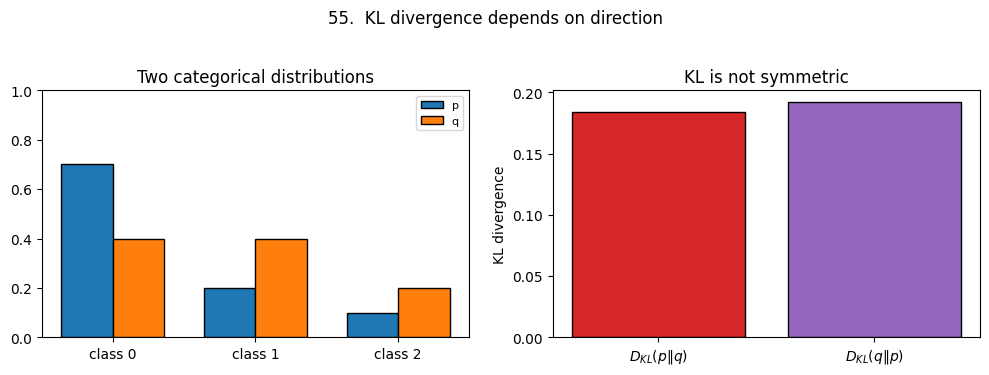

In [55]:
import matplotlib.pyplot as plt
import numpy as np

p = np.array([0.7, 0.2, 0.1])
q = np.array([0.4, 0.4, 0.2])
kl_pq = np.sum(p * np.log(p / q))
kl_qp = np.sum(q * np.log(q / p))

print("55) D_KL(p || q) =", kl_pq)
print("    D_KL(q || p) =", kl_qp)

x = np.arange(len(p))
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].bar(x - 0.18, p, width=0.36, label="p", color="C0", edgecolor="k")
axes[0].bar(x + 0.18, q, width=0.36, label="q", color="C1", edgecolor="k")
axes[0].set_xticks(x)
axes[0].set_xticklabels(["class 0", "class 1", "class 2"])
axes[0].set_ylim(0, 1)
axes[0].set_title("Two categorical distributions")
axes[0].legend(fontsize=8)

axes[1].bar([r"$D_{KL}(p\|q)$", r"$D_{KL}(q\|p)$"], [kl_pq, kl_qp], color=["C3", "C4"], edgecolor="k")
axes[1].set_ylabel("KL divergence")
axes[1].set_title("KL is not symmetric")

plt.suptitle(r"55.  KL divergence depends on direction", y=1.03)
plt.tight_layout()
plt.show()


**What the visual shows:** The two KL values differ because each direction weights mistakes by a different reference distribution.


## 56. Entropy $H(X)$

**Notation:** For a discrete random variable, $H(X)=-\sum_x P(x)\log P(x)$.

**Theory:** Entropy measures uncertainty or average information content. A deterministic variable has entropy $0$; a uniform distribution has high entropy because outcomes are hard to predict.

**Math example:** A Bernoulli variable has $H(p)=-p\log p-(1-p)\log(1-p)$, maximized at $p=0.5$.


**Best example:** Compare low-entropy and high-entropy Bernoulli distributions.

**Visualize:** Bernoulli entropy as a function of $p$.


56) Bernoulli entropy values: [(0.1, 0.4689955935892812), (0.5, 1.0), (0.9, 0.4689955935892811)]


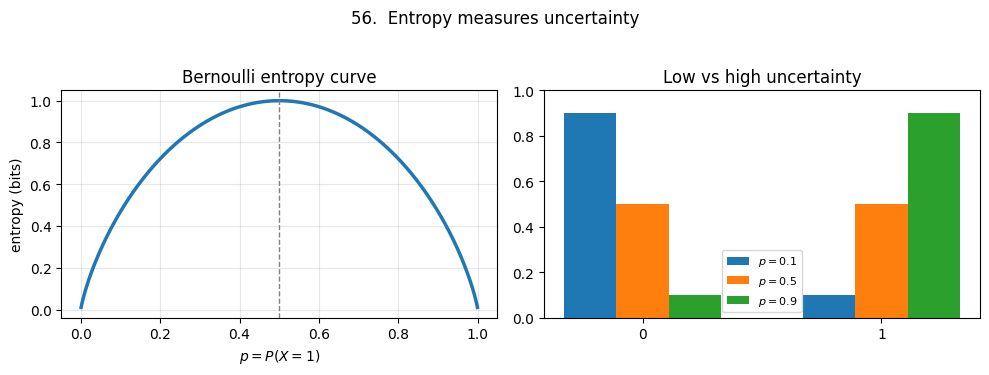

In [56]:
import matplotlib.pyplot as plt
import numpy as np

p = np.linspace(0.001, 0.999, 400)
H = -(p * np.log2(p) + (1 - p) * np.log2(1 - p))
examples = [0.1, 0.5, 0.9]

print("56) Bernoulli entropy values:", [(v, float(-(v*np.log2(v)+(1-v)*np.log2(1-v)))) for v in examples])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(p, H, "C0", lw=2.5)
axes[0].axvline(0.5, color="gray", ls="--", lw=1)
axes[0].set_xlabel(r"$p=P(X=1)$")
axes[0].set_ylabel("entropy (bits)")
axes[0].set_title("Bernoulli entropy curve")
axes[0].grid(True, alpha=0.3)

width = 0.22
for i, val in enumerate(examples):
    axes[1].bar(np.array([0, 1]) + (i - 1) * width, [1 - val, val], width=width, label=rf"$p={val}$")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["0", "1"])
axes[1].set_ylim(0, 1)
axes[1].set_title("Low vs high uncertainty")
axes[1].legend(fontsize=8)

plt.suptitle(r"56.  Entropy measures uncertainty", y=1.03)
plt.tight_layout()
plt.show()


**What the visual shows:** Entropy is low when one outcome is almost certain and high when both outcomes are balanced.


## 57. Conditional probability $P(A\mid B)$

**Notation:** $P(A\mid B)=\frac{P(A\cap B)}{P(B)}$ when $P(B)>0$.

**Theory:** Conditioning changes the sample space to cases where $B$ has occurred. This is the basis of Bayes' rule, probabilistic inference, and many ML models.

**Math example:** If $P(A\cap B)=0.2$ and $P(B)=0.5$, then $P(A\mid B)=0.4$.


**Best example:** Use a rectangle model where conditioning on $B$ turns $B$ into the new sample space.

**Visualize:** event $B$ as the new denominator and $A\cap B$ as the successful part inside it.


57) P(A|B) = P(A and B)/P(B) = 0.4


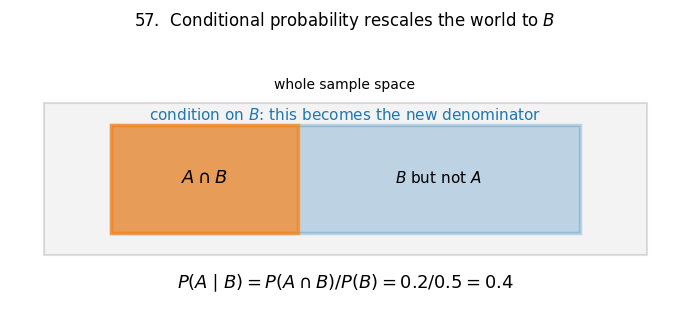

In [57]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

P_B = 0.5
P_A_and_B = 0.2
P_A_given_B = P_A_and_B / P_B
print("57) P(A|B) = P(A and B)/P(B) =", P_A_given_B)

fig, ax = plt.subplots(figsize=(7, 3.3))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

world = Rectangle((0.05, 0.2), 0.9, 0.55, facecolor="lightgray", alpha=0.25, edgecolor="gray", lw=1.5)
B = Rectangle((0.15, 0.28), 0.70, 0.39, facecolor="C0", alpha=0.25, edgecolor="C0", lw=2.5)
AB = Rectangle((0.15, 0.28), 0.28, 0.39, facecolor="C1", alpha=0.65, edgecolor="C1", lw=2.5)
for patch in [world, B, AB]:
    ax.add_patch(patch)

ax.text(0.5, 0.80, "whole sample space", ha="center", fontsize=10)
ax.text(0.5, 0.69, r"condition on $B$: this becomes the new denominator", ha="center", fontsize=11, color="C0")
ax.text(0.29, 0.48, r"$A\cap B$", ha="center", va="center", fontsize=13)
ax.text(0.64, 0.48, r"$B$ but not $A$", ha="center", va="center", fontsize=11)
ax.text(0.5, 0.08, rf"$P(A\mid B)=P(A\cap B)/P(B)={P_A_and_B}/{P_B}={P_A_given_B:.1f}$", ha="center", fontsize=13)
ax.set_title(r"57.  Conditional probability rescales the world to $B$")
plt.tight_layout()
plt.show()


**What the visual shows:** After conditioning, the blue rectangle $B$ becomes the denominator. The orange region is the part of $B$ where $A$ also occurs.


## 58. i.i.d. random variables

**Notation:** i.i.d. means **independent and identically distributed**. We often write $X_1,\ldots,X_n\overset{\mathrm{i.i.d.}}{\sim}p$.

**Theory:** Independent means one draw does not reveal information about another; identically distributed means each draw follows the same distribution. Many learning algorithms assume training examples are i.i.d. samples from an unknown data distribution.

**Math example:** Repeated fair die rolls are i.i.d. with $P(X=k)=1/6$ for $k=1,\ldots,6$.


**Best example:** Compare i.i.d. samples with non-i.i.d. drifting samples.

**Visualize:** two independent sample coordinates with no systematic pattern.


58) iid first-half mean vs second-half mean: 0.06025986775271709 -0.10034401157721687
    drifting first-half mean vs second-half mean: -0.7327548391239397 0.7780743835357286


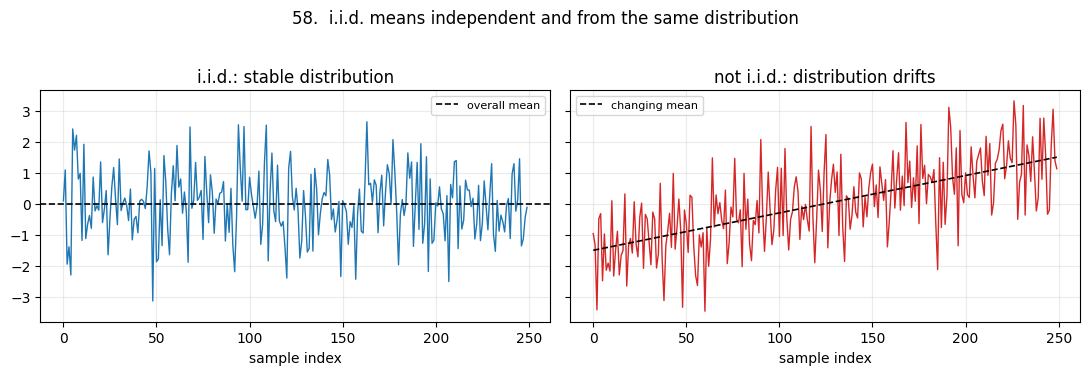

In [58]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(8)
n = 250
iid = np.random.normal(0, 1, n)
drift = np.random.normal(np.linspace(-1.5, 1.5, n), 1.0)

print("58) iid first-half mean vs second-half mean:", iid[:n//2].mean(), iid[n//2:].mean())
print("    drifting first-half mean vs second-half mean:", drift[:n//2].mean(), drift[n//2:].mean())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
axes[0].plot(iid, color="C0", lw=1)
axes[0].axhline(iid.mean(), color="black", ls="--", lw=1.2, label="overall mean")
axes[0].set_title("i.i.d.: stable distribution")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.25)

axes[1].plot(drift, color="C3", lw=1)
axes[1].plot(np.linspace(-1.5, 1.5, n), color="black", ls="--", lw=1.2, label="changing mean")
axes[1].set_title("not i.i.d.: distribution drifts")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.25)

for ax in axes:
    ax.set_xlabel("sample index")

plt.suptitle(r"58.  i.i.d. means independent and from the same distribution", y=1.03)
plt.tight_layout()
plt.show()


**What the visual shows:** The i.i.d. sequence has stable behavior over time. The drifting sequence changes its distribution, violating the identical-distribution part of i.i.d.


## 59. Jacobian $J_f(\mathbf{x})$

**Notation:** For $f:\mathbb{R}^n\to\mathbb{R}^m$, the Jacobian is the matrix of first partial derivatives: $(J_f)_{ij}=\frac{\partial f_i}{\partial x_j}$.

**Theory:** The Jacobian is the best local linear approximation to a vector-valued function. Near a point, $f(\mathbf{x}+\Delta\mathbf{x})\approx f(\mathbf{x})+J_f(\mathbf{x})\Delta\mathbf{x}$. Backpropagation is built from Jacobians and their products.

**Math example:** If $f(x,y)=(x+0.5y,0.5x+y)$, then $J_f=\begin{bmatrix}1&0.5\\0.5&1\end{bmatrix}$.


**Best example:** Show a nonlinear map and its local Jacobian approximation around one point.

**Visualize:** grid before and after a linear map.


59) Jacobian at [1.  0.8] =
 [[1.   0.48]
 [0.4  1.  ]]


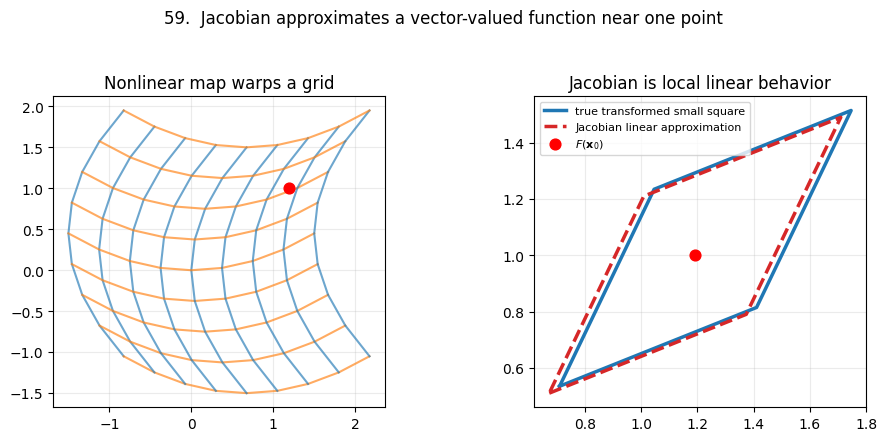

In [59]:
import matplotlib.pyplot as plt
import numpy as np

def F(points):
    x, y = points[..., 0], points[..., 1]
    return np.stack([x + 0.30 * y ** 2, y + 0.20 * x ** 2], axis=-1)

def J_at(p):
    x, y = p
    return np.array([[1.0, 0.60 * y], [0.40 * x, 1.0]])

p0 = np.array([1.0, 0.8])
J = J_at(p0)
eps = 0.35
square = np.array([[-eps, -eps], [eps, -eps], [eps, eps], [-eps, eps], [-eps, -eps]])
local_input = p0 + square
true_output = F(local_input)
linear_output = F(p0) + square @ J.T

print("59) Jacobian at", p0, "=\n", J)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
grid = np.linspace(-1.5, 1.5, 9)
for g in grid:
    pts = np.c_[np.full_like(grid, g), grid]
    out = F(pts)
    axes[0].plot(out[:, 0], out[:, 1], color="C0", alpha=0.65)
    pts = np.c_[grid, np.full_like(grid, g)]
    out = F(pts)
    axes[0].plot(out[:, 0], out[:, 1], color="C1", alpha=0.65)
axes[0].scatter(*F(p0), color="red", s=60, zorder=5)
axes[0].set_title("Nonlinear map warps a grid")
axes[0].set_aspect("equal")
axes[0].grid(True, alpha=0.25)

axes[1].plot(true_output[:, 0], true_output[:, 1], "C0", lw=2.5, label="true transformed small square")
axes[1].plot(linear_output[:, 0], linear_output[:, 1], "C3--", lw=2.5, label="Jacobian linear approximation")
axes[1].scatter(*F(p0), color="red", s=60, zorder=5, label=r"$F(\mathbf{x}_0)$")
axes[1].set_title("Jacobian is local linear behavior")
axes[1].set_aspect("equal")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.25)

plt.suptitle(r"59.  Jacobian approximates a vector-valued function near one point", y=1.04)
plt.tight_layout()
plt.show()


**What the visual shows:** The nonlinear map curves space globally. Near one point, the Jacobian gives a linear approximation that matches the transformed tiny square.


## 60. Hessian $\nabla^2 f(\mathbf{x})$

**Notation:** The Hessian is the matrix of second partial derivatives: $(\nabla^2 f)_{ij}=\frac{\partial^2 f}{\partial x_i\partial x_j}$.

**Theory:** The Hessian describes curvature. Positive eigenvalues mean the function curves upward in those directions; negative eigenvalues mean downward curvature. Optimization methods use Hessians to reason about minima, maxima, saddle points, and Newton steps.

**Math example:** For $f(x,y)=x^2+3y^2$, $\nabla^2 f=\begin{bmatrix}2&0\\0&6\end{bmatrix}$.


**Best example:** Compare Hessian curvature for a minimum, maximum, and saddle point.

**Visualize:** elliptical contours of a quadratic function and its Hessian heatmap.


60) Hessian eigenvalue signs classify local quadratic shape:
    minimum [2. 2.] all eigenvalues > 0
    maximum [-2. -2.] all eigenvalues < 0
    saddle [-2.  2.] mixed signs


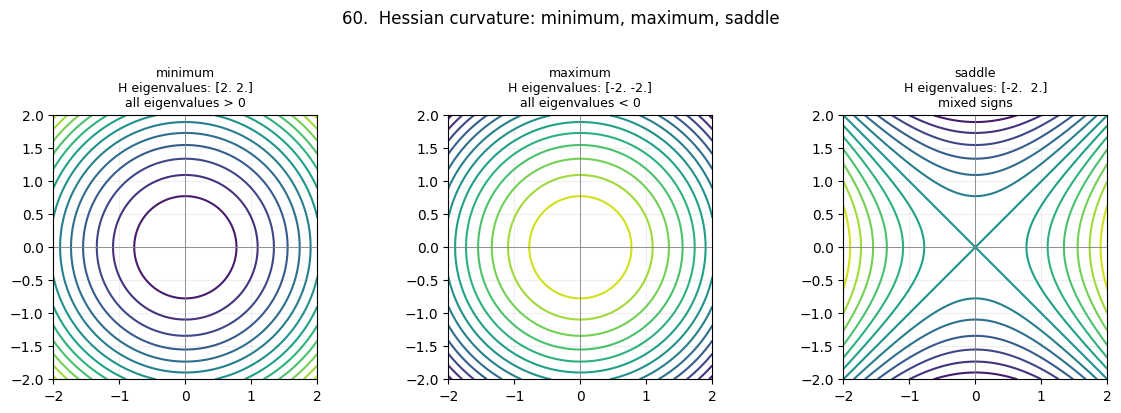

In [60]:
import matplotlib.pyplot as plt
import numpy as np

xg = np.linspace(-2, 2, 160)
yg = np.linspace(-2, 2, 160)
X, Y = np.meshgrid(xg, yg)
cases = [
    ("minimum", X ** 2 + Y ** 2, np.array([[2.0, 0.0], [0.0, 2.0]]), "all eigenvalues > 0"),
    ("maximum", -(X ** 2 + Y ** 2), np.array([[-2.0, 0.0], [0.0, -2.0]]), "all eigenvalues < 0"),
    ("saddle", X ** 2 - Y ** 2, np.array([[2.0, 0.0], [0.0, -2.0]]), "mixed signs"),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, (name, Z, H, subtitle) in zip(axes, cases):
    cs = ax.contour(X, Y, Z, levels=14, cmap="viridis")
    ax.axhline(0, color="gray", lw=0.6)
    ax.axvline(0, color="gray", lw=0.6)
    ax.set_aspect("equal")
    ax.set_title(f"{name}\nH eigenvalues: {np.linalg.eigvalsh(H)}\n{subtitle}", fontsize=9)
    ax.grid(True, alpha=0.2)

print("60) Hessian eigenvalue signs classify local quadratic shape:")
for name, _, H, subtitle in cases:
    print("   ", name, np.linalg.eigvalsh(H), subtitle)

plt.suptitle(r"60.  Hessian curvature: minimum, maximum, saddle", y=1.05)
plt.tight_layout()
plt.show()


**What the visual shows:** The minimum curves upward in all directions, the maximum curves downward, and the saddle curves upward in one direction and downward in another.
